# Task 2 GNN on Music Structure Graphs

Goal

Use FMA small audio to build musical segment graphs and classify eight music genres with GraphSAGE.

A convolutional neural network on log mel spectrograms and a majority class predictor are used as baselines.

  




In [1]:
# CELL 1  Install required packages

!pip -q install torch-geometric librosa==0.10.2.post1 soundfile joblib networkx

print("Required packages are ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 917.4 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 3.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.6 MB/s eta 0:00:0000:0100:01
Required packages are ready.


In [2]:
# CELL 2  Imports and reproducibility

import os
import sys
import gc
import json
import math
import time
import random
import shutil
import warnings
import subprocess
import tempfile

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import networkx as nx
import joblib

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    silhouette_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader as TorchDataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python version:", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("librosa version:", librosa.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python version: 3.12.13
PyTorch version: 2.10.0+cu128
librosa version: 0.10.2.post1
CUDA available: True
GPU: Tesla T4


In [3]:
# CELL 3  Experiment configuration and folders

SR = 22050
DURATION = 30.0
N_FFT = 2048
HOP = 512

BEATS_PER_NODE = 4
MIN_SEGMENT_SEC = 1.0
FALLBACK_SEGMENT_SEC = 3.0
MIN_NODES = 6
MAX_NODES = 24

GRAPH_N_MELS = 64
N_MFCC = 20

SIM_THRESHOLD = 0.50
SIM_TOP_K = 3

GNN_HIDDEN = 192
GNN_DROPOUT = 0.25
GNN_EDGE_DROPOUT = 0.10
BATCH_SIZE_GNN = 48
EPOCHS_GNN = 50
LR_GNN = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
LABEL_SMOOTHING = 0.05

CNN_N_MELS = 128
CNN_IMAGE_TIME = 256
BATCH_SIZE_CNN = 48
EPOCHS_CNN = 35
LR_CNN = 7e-4

FAST_DEV_RUN = False
DEV_TRAIN = 800
DEV_VALIDATION = 200
DEV_TEST = 200

KAGGLE_WORKING = Path("/kaggle/working")

if not KAGGLE_WORKING.exists():
    KAGGLE_WORKING = Path("./kaggle_working")
    KAGGLE_WORKING.mkdir(parents=True, exist_ok=True)

GITHUB_DIR = KAGGLE_WORKING / "task2_fma_github"
CACHE_DIR = KAGGLE_WORKING / "task2_fma_runtime_cache"

RAW_GRAPH_DIR = CACHE_DIR / "raw_graphs"
MEL_DIR = CACHE_DIR / "mel_cache"

METRICS_DIR = GITHUB_DIR / "metrics"
PLOT_DIR = GITHUB_DIR / "plots"
SPLIT_DIR = GITHUB_DIR / "data_splits"
SAMPLE_DIR = GITHUB_DIR / "graph_samples_24"
EXAMPLES_DIR = GITHUB_DIR / "examples"
CONFIG_DIR = GITHUB_DIR / "config"
PREPROCESSING_DIR = GITHUB_DIR / "preprocessing"

for folder in [
    GITHUB_DIR,
    CACHE_DIR,
    RAW_GRAPH_DIR,
    MEL_DIR,
    METRICS_DIR,
    PLOT_DIR,
    SPLIT_DIR,
    SAMPLE_DIR,
    EXAMPLES_DIR,
    CONFIG_DIR,
    PREPROCESSING_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("GitHub output folder:", GITHUB_DIR)
print("Runtime cache folder:", CACHE_DIR)

Device: cuda
GitHub output folder: /kaggle/working/task2_fma_github
Runtime cache folder: /kaggle/working/task2_fma_runtime_cache


In [4]:
# CELL 4  Find FMA metadata and audio

INPUT_ROOT = Path("/kaggle/input")

def find_metadata_file(name):
    candidates = [
        path
        for path in INPUT_ROOT.rglob(name)
        if path.is_file()
    ]

    preferred = [
        path
        for path in candidates
        if "fma_metadata" in path.parts
    ]

    if preferred:
        return preferred[0]

    if candidates:
        return candidates[0]

    return None

def find_audio_root():
    candidates = []

    for path in INPUT_ROOT.rglob("fma_small"):
        if (
            path.is_dir()
            and (path / "000").is_dir()
            and any((path / "000").glob("*.mp3"))
        ):
            candidates.append(path)

    if not candidates:
        return None

    return sorted(
        candidates,
        key=lambda path: len(path.parts),
        reverse=True,
    )[0]

TRACKS_CSV = find_metadata_file("tracks.csv")
GENRES_CSV = find_metadata_file("genres.csv")
AUDIO_DIR = find_audio_root()

print("Tracks metadata:", TRACKS_CSV)
print("Genres metadata:", GENRES_CSV)
print("Audio folder:", AUDIO_DIR)

assert TRACKS_CSV is not None, "tracks.csv was not found."
assert AUDIO_DIR is not None, "The inner fma_small audio folder was not found."

Tracks metadata: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
Genres metadata: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/genres.csv
Audio folder: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small/fma_small


In [5]:
# CELL 5  Load official FMA small metadata

tracks = pd.read_csv(
    TRACKS_CSV,
    index_col=0,
    header=[0, 1],
)

small = tracks[
    (tracks[("set", "subset")].astype(str) == "small")
    & tracks[("track", "genre_top")].notna()
].copy()

meta = pd.DataFrame({
    "track_id": small.index.astype(int),
    "split": small[("set", "split")].astype(str).values,
    "genre": small[("track", "genre_top")].astype(str).values,
    "title": small[("track", "title")].astype(str).values,
    "artist_id": small[("artist", "id")].values,
})

genres = sorted(meta["genre"].unique())

genre_to_index = {
    genre: index
    for index, genre in enumerate(genres)
}

index_to_genre = {
    index: genre
    for genre, index in genre_to_index.items()
}

meta["label"] = (
    meta["genre"]
    .map(genre_to_index)
    .astype(int)
)

def audio_path(track_id):
    track_text = f"{int(track_id):06d}"
    return (
        AUDIO_DIR
        / track_text[:3]
        / f"{track_text}.mp3"
    )

meta["audio_path"] = meta["track_id"].map(
    lambda track_id: str(audio_path(track_id))
)

meta["exists"] = meta["audio_path"].map(
    os.path.exists
)

print("Metadata rows:", len(meta))
print("Missing audio files:", int((~meta["exists"]).sum()))

meta = (
    meta[meta["exists"]]
    .drop(columns="exists")
    .reset_index(drop=True)
)

split_table = pd.crosstab(
    meta["genre"],
    meta["split"],
)

display(split_table)

split_table.to_csv(
    METRICS_DIR / "dataset_split_distribution.csv"
)

with open(
    CONFIG_DIR / "genre_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "genre_to_index": genre_to_index,
            "index_to_genre": {
                str(key): value
                for key, value in index_to_genre.items()
            },
        },
        file,
        indent=2,
    )

Metadata rows: 8000
Missing audio files: 0


split,test,training,validation
genre,,,
Electronic,100,800,100
Experimental,100,800,100
Folk,100,800,100
Hip-Hop,100,800,100
Instrumental,100,800,100
International,100,800,100
Pop,100,800,100
Rock,100,800,100


In [6]:
# CELL 6  Check artist overlap across official splits

artist_sets = {
    split_name: set(
        meta.loc[
            meta["split"] == split_name,
            "artist_id",
        ]
        .dropna()
        .astype(int)
    )
    for split_name in [
        "training",
        "validation",
        "test",
    ]
}

artist_overlap = {
    "training_validation_artist_overlap": len(
        artist_sets["training"]
        & artist_sets["validation"]
    ),
    "training_test_artist_overlap": len(
        artist_sets["training"]
        & artist_sets["test"]
    ),
    "validation_test_artist_overlap": len(
        artist_sets["validation"]
        & artist_sets["test"]
    ),
}

print(json.dumps(artist_overlap, indent=2))

with open(
    METRICS_DIR / "artist_overlap_check.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        artist_overlap,
        file,
        indent=2,
    )

{
  "training_validation_artist_overlap": 0,
  "training_test_artist_overlap": 0,
  "validation_test_artist_overlap": 0
}


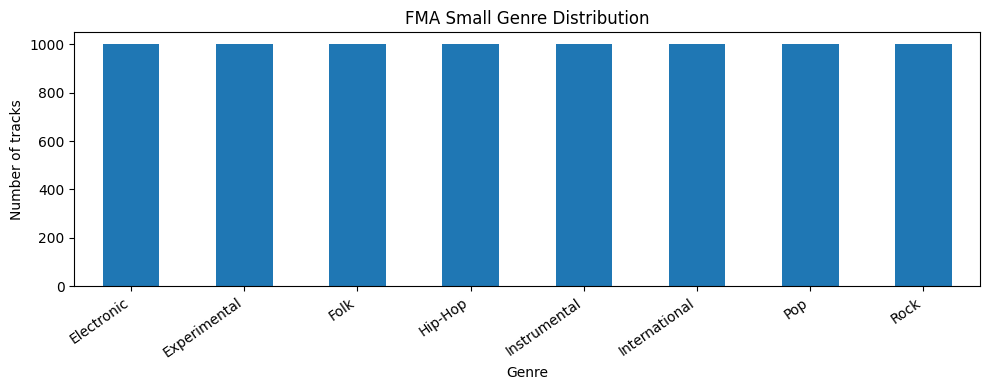

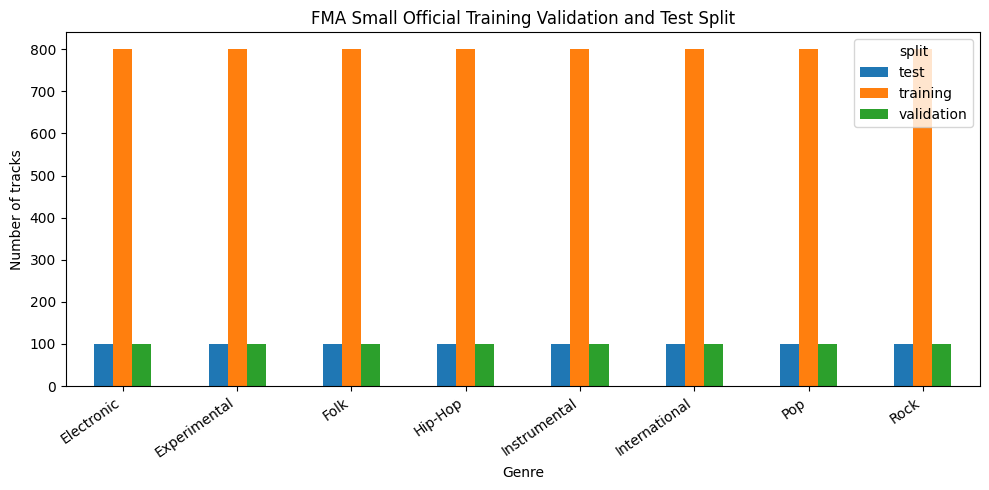

In [7]:
# CELL 7  Dataset distribution plots

plt.figure(figsize=(10, 4))

meta["genre"].value_counts().reindex(
    genres
).plot(kind="bar")

plt.title("FMA Small Genre Distribution")
plt.ylabel("Number of tracks")
plt.xlabel("Genre")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "genre_distribution.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

split_table.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "FMA Small Official Training Validation and Test Split"
)

plt.ylabel("Number of tracks")
plt.xlabel("Genre")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "split_distribution.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [8]:
# CELL 8  Robust audio loader

AUDIO_LOG = []

def safe_load_audio(
    path,
    track_id=None,
    sr=SR,
    duration=DURATION,
):
    target = int(sr * duration)
    backend = "librosa"

    try:
        y, _ = librosa.load(
            path,
            sr=sr,
            mono=True,
            duration=duration,
        )

    except Exception:
        backend = "ffmpeg_fallback"

        temp_path = (
            Path(tempfile.gettempdir())
            / f"fma_{track_id or 'temp'}.wav"
        )

        try:
            command = [
                "ffmpeg",
                "-v",
                "error",
                "-y",
                "-i",
                str(path),
                "-ac",
                "1",
                "-ar",
                str(sr),
                str(temp_path),
            ]

            subprocess.run(
                command,
                check=True,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
            )

            y, native_sr = sf.read(
                temp_path,
                always_2d=False,
            )

            if y.ndim > 1:
                y = y.mean(axis=1)

            if native_sr != sr:
                y = librosa.resample(
                    y.astype(np.float32),
                    orig_sr=native_sr,
                    target_sr=sr,
                )

            y = y[:target]

        finally:
            try:
                temp_path.unlink(missing_ok=True)
            except Exception:
                pass

    y = np.asarray(
        y,
        dtype=np.float32,
    )

    if len(y) == 0 or not np.isfinite(y).all():
        raise ValueError(
            "Decoded audio is empty or contains invalid values."
        )

    original_length = len(y)

    if len(y) < target:
        if len(y) < int(0.80 * target):
            raise ValueError(
                f"Decode too short: {len(y) / sr:.2f} seconds"
            )

        y = np.pad(
            y,
            (0, target - len(y)),
        )

    else:
        y = y[:target]

    peak = float(
        np.max(np.abs(y))
    )

    rms = float(
        np.sqrt(
            np.mean(y ** 2)
            + 1e-12
        )
    )

    if peak < 1e-5 or rms < 1e-6:
        raise ValueError(
            "Near silent decoded track."
        )

    AUDIO_LOG.append({
        "track_id": (
            int(track_id)
            if track_id is not None
            else -1
        ),
        "backend": backend,
        "decoded_seconds_before_padding": (
            original_length / sr
        ),
        "peak": peak,
        "rms": rms,
    })

    return y

Track ID: 54033
Genre: Pop
Title: Snow Wave
Duration in seconds: 30.0


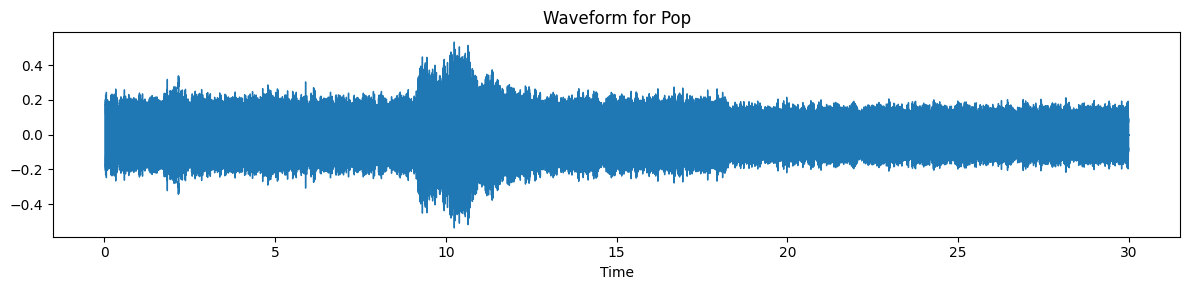

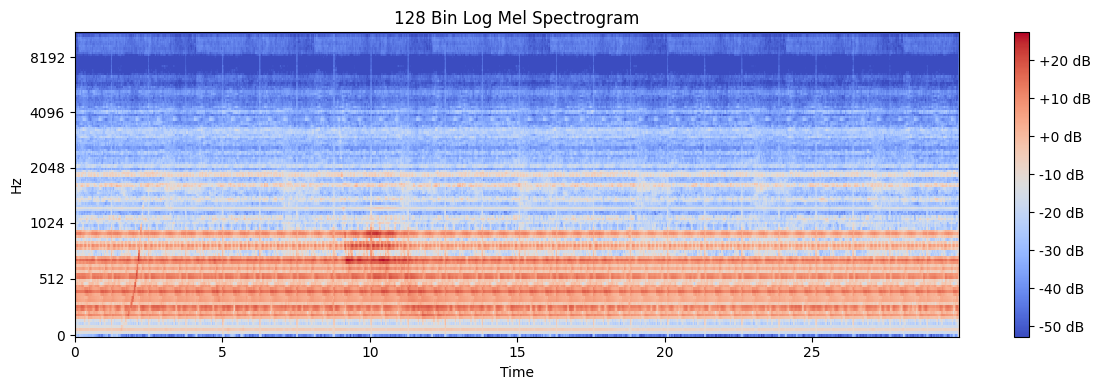

In [9]:
# CELL 9  Visualize one audio example

example = (
    meta.sample(
        1,
        random_state=SEED,
    )
    .iloc[0]
)

y = safe_load_audio(
    example["audio_path"],
    example["track_id"],
)

print("Track ID:", example["track_id"])
print("Genre:", example["genre"])
print("Title:", example["title"])
print("Duration in seconds:", len(y) / SR)

plt.figure(figsize=(12, 3))

librosa.display.waveshow(
    y,
    sr=SR,
)

plt.title(
    f"Waveform for {example['genre']}"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "example_waveform.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

mel = librosa.feature.melspectrogram(
    y=y,
    sr=SR,
    n_fft=N_FFT,
    hop_length=HOP,
    n_mels=128,
)

mel_db = librosa.power_to_db(
    mel,
    ref=1.0,
)

plt.figure(figsize=(12, 4))

librosa.display.specshow(
    mel_db,
    sr=SR,
    hop_length=HOP,
    x_axis="time",
    y_axis="mel",
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    "128 Bin Log Mel Spectrogram"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "example_log_mel_spectrogram.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Build musical segment nodes

Each track is divided using beat locations.

Four beats are grouped into one bar like segment.

If beat tracking does not produce a useful number of segments, fixed three second segments are used.

Each segment receives 228 features made from the mean and standard deviation of log mel, MFCC, chroma, spectral contrast, tonnetz, and spectral statistics.

In [10]:
# CELL 10  Frame level audio features

def frame_features(y):
    stft = np.abs(
        librosa.stft(
            y,
            n_fft=N_FFT,
            hop_length=HOP,
        )
    )

    power = stft ** 2

    mel = librosa.feature.melspectrogram(
        S=power,
        sr=SR,
        n_mels=GRAPH_N_MELS,
        n_fft=N_FFT,
        hop_length=HOP,
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=1.0,
    )

    mfcc = librosa.feature.mfcc(
        S=log_mel,
        n_mfcc=N_MFCC,
    )

    chroma = librosa.feature.chroma_stft(
        S=power,
        sr=SR,
        n_chroma=12,
    )

    contrast = librosa.feature.spectral_contrast(
        S=stft,
        sr=SR,
        n_bands=6,
    )

    tonnetz = librosa.feature.tonnetz(
        chroma=chroma,
        sr=SR,
    )

    centroid = librosa.feature.spectral_centroid(
        S=stft,
        sr=SR,
    )

    bandwidth = librosa.feature.spectral_bandwidth(
        S=stft,
        sr=SR,
    )

    rolloff = librosa.feature.spectral_rolloff(
        S=stft,
        sr=SR,
    )

    zero_crossing_rate = (
        librosa.feature.zero_crossing_rate(
            y,
            frame_length=N_FFT,
            hop_length=HOP,
        )
    )

    rms = librosa.feature.rms(
        S=stft,
        frame_length=N_FFT,
        hop_length=HOP,
    )

    arrays = [
        log_mel,
        mfcc,
        chroma,
        contrast,
        tonnetz,
        centroid,
        bandwidth,
        rolloff,
        zero_crossing_rate,
        rms,
    ]

    frame_count = min(
        array.shape[1]
        for array in arrays
    )

    arrays = [
        array[:, :frame_count]
        for array in arrays
    ]

    full_features = np.vstack(
        arrays
    ).astype(np.float32)

    similarity_features = np.vstack([
        mfcc[:13, :frame_count],
        chroma[:, :frame_count],
        contrast[:, :frame_count],
    ]).astype(np.float32)

    return (
        full_features,
        similarity_features,
    )

In [11]:
# CELL 11  Musical segment boundaries

def fixed_boundaries(
    duration=DURATION,
    segment_seconds=FALLBACK_SEGMENT_SEC,
):
    boundaries = (
        list(
            np.arange(
                0,
                duration,
                segment_seconds,
            )
        )
        + [duration]
    )

    boundaries = np.asarray(
        sorted(
            set(
                float(value)
                for value in boundaries
            )
        ),
        dtype=np.float32,
    )

    return (
        boundaries,
        "fixed_fallback",
    )

def beat_bar_boundaries(y):
    try:
        tempo, beat_frames = (
            librosa.beat.beat_track(
                y=y,
                sr=SR,
                hop_length=HOP,
            )
        )

        beat_frames = np.asarray(
            beat_frames
        ).reshape(-1)

        beat_times = librosa.frames_to_time(
            beat_frames,
            sr=SR,
            hop_length=HOP,
        )

        if len(beat_times) < 8:
            return fixed_boundaries()

        raw_boundaries = (
            [0.0]
            + list(
                beat_times[::BEATS_PER_NODE]
            )
            + [DURATION]
        )

        raw_boundaries = np.asarray(
            sorted(
                set(
                    float(
                        np.clip(
                            value,
                            0,
                            DURATION,
                        )
                    )
                    for value in raw_boundaries
                )
            )
        )

        kept = [
            raw_boundaries[0]
        ]

        for value in raw_boundaries[1:-1]:
            if (
                value - kept[-1]
                >= MIN_SEGMENT_SEC
            ):
                kept.append(value)

        if (
            DURATION - kept[-1]
            < MIN_SEGMENT_SEC
            and len(kept) > 1
        ):
            kept[-1] = DURATION
        else:
            kept.append(DURATION)

        boundaries = np.asarray(
            sorted(set(kept)),
            dtype=np.float32,
        )

        number_of_nodes = (
            len(boundaries) - 1
        )

        if (
            number_of_nodes < MIN_NODES
            or number_of_nodes > MAX_NODES
        ):
            return fixed_boundaries()

        return (
            boundaries,
            "beat_bar",
        )

    except Exception:
        return fixed_boundaries()

In [12]:
# CELL 12  Aggregate frames into node features

def l2_normalize(vector):
    return (
        vector
        / (
            np.linalg.norm(vector)
            + 1e-8
        )
    )

def aggregate_nodes(y):
    full_features, similarity_features = (
        frame_features(y)
    )

    boundaries, segmentation_mode = (
        beat_bar_boundaries(y)
    )

    node_features = []
    similarity_vectors = []

    for start_seconds, end_seconds in zip(
        boundaries[:-1],
        boundaries[1:],
    ):
        start_frame = int(
            librosa.time_to_frames(
                start_seconds,
                sr=SR,
                hop_length=HOP,
            )
        )

        end_frame = int(
            librosa.time_to_frames(
                end_seconds,
                sr=SR,
                hop_length=HOP,
            )
        )

        start_frame = max(
            0,
            min(
                start_frame,
                full_features.shape[1] - 1,
            ),
        )

        end_frame = max(
            start_frame + 1,
            min(
                end_frame,
                full_features.shape[1],
            ),
        )

        segment = full_features[
            :,
            start_frame:end_frame,
        ]

        node = np.concatenate([
            segment.mean(axis=1),
            segment.std(axis=1),
        ]).astype(np.float32)

        node_features.append(node)

        similarity_segment = (
            similarity_features[
                :,
                start_frame:end_frame,
            ]
            .mean(axis=1)
        )

        mfcc_block = l2_normalize(
            similarity_segment[:13]
        )

        chroma_block = l2_normalize(
            similarity_segment[13:25]
        )

        contrast_block = l2_normalize(
            similarity_segment[25:32]
        )

        similarity_vector = l2_normalize(
            np.concatenate([
                mfcc_block,
                chroma_block,
                contrast_block,
            ])
        ).astype(np.float32)

        similarity_vectors.append(
            similarity_vector
        )

    node_matrix = np.stack(
        node_features
    ).astype(np.float32)

    similarity_matrix = np.stack(
        similarity_vectors
    ).astype(np.float32)

    return (
        node_matrix,
        similarity_matrix,
        boundaries,
        segmentation_mode,
    )

In [13]:
# CELL 13  Check segmentation and feature dimensions

example_nodes, example_similarity_vectors, example_boundaries, example_segmentation_mode = (
    aggregate_nodes(y)
)

print("Segmentation mode:", example_segmentation_mode)
print(
    "Segment boundaries in seconds:",
    np.round(
        example_boundaries,
        2,
    ),
)
print("Number of graph nodes:", len(example_nodes))
print(
    "Node feature dimension:",
    example_nodes.shape[1],
)
print(
    "Similarity feature dimension:",
    example_similarity_vectors.shape[1],
)

assert example_nodes.shape[1] == 228

Segmentation mode: beat_bar
Segment boundaries in seconds: [ 0.    2.53  7.57 12.61 17.62 22.66 27.7  30.  ]
Number of graph nodes: 7
Node feature dimension: 228
Similarity feature dimension: 32


# Build graph edges

Every graph contains temporal edges between consecutive segments.

It also contains non local similarity edges between acoustically similar segments.

Cosine similarity must be at least 0.50, and each node can add up to three non local similarity neighbors.

In [14]:
# CELL 14  Build temporal and similarity edges

def build_edges(
    similarity_vectors,
    threshold=SIM_THRESHOLD,
    top_k=SIM_TOP_K,
):
    number_of_nodes = len(
        similarity_vectors
    )

    edge_map = {}

    for node_index in range(
        number_of_nodes - 1
    ):
        edge_map[
            (node_index, node_index + 1)
        ] = 0

        edge_map[
            (node_index + 1, node_index)
        ] = 0

    cosine_similarity = (
        similarity_vectors
        @ similarity_vectors.T
    )

    np.fill_diagonal(
        cosine_similarity,
        -np.inf,
    )

    for node_index in range(
        number_of_nodes
    ):
        order = np.argsort(
            cosine_similarity[node_index]
        )[::-1]

        added = 0

        for neighbor_index in order:
            neighbor_index = int(
                neighbor_index
            )

            if (
                abs(
                    node_index
                    - neighbor_index
                )
                <= 1
            ):
                continue

            if (
                cosine_similarity[
                    node_index,
                    neighbor_index,
                ]
                < threshold
            ):
                break

            if (
                node_index,
                neighbor_index,
            ) not in edge_map:
                edge_map[
                    (
                        node_index,
                        neighbor_index,
                    )
                ] = 1

            if (
                neighbor_index,
                node_index,
            ) not in edge_map:
                edge_map[
                    (
                        neighbor_index,
                        node_index,
                    )
                ] = 1

            added += 1

            if added >= top_k:
                break

    pairs = sorted(
        edge_map.keys()
    )

    edge_index = torch.tensor(
        pairs,
        dtype=torch.long,
    ).t().contiguous()

    edge_type = torch.tensor(
        [
            edge_map[pair]
            for pair in pairs
        ],
        dtype=torch.long,
    )

    return (
        edge_index,
        edge_type,
        cosine_similarity,
    )

In [15]:
# CELL 15  Convert one track into a PyTorch Geometric graph

def track_to_graph(row):
    audio = safe_load_audio(
        row["audio_path"],
        row["track_id"],
    )

    node_features, similarity_vectors, boundaries, segmentation_mode = (
        aggregate_nodes(audio)
    )

    edge_index, edge_type, similarity = (
        build_edges(
            similarity_vectors
        )
    )

    graph = Data(
        x=torch.tensor(
            node_features,
            dtype=torch.float32,
        ),
        edge_index=edge_index,
        edge_type=edge_type,
        y=torch.tensor(
            [int(row["label"])],
            dtype=torch.long,
        ),
        track_id=torch.tensor(
            [int(row["track_id"])],
            dtype=torch.long,
        ),
    )

    graph.segmentation_mode = (
        segmentation_mode
    )

    graph.boundaries = torch.tensor(
        boundaries,
        dtype=torch.float32,
    )

    return (
        graph,
        similarity,
    )

Number of nodes: 7
Number of directed edges: 38
Temporal directed edges: 12
Similarity directed edges: 26
Segmentation mode: beat_bar


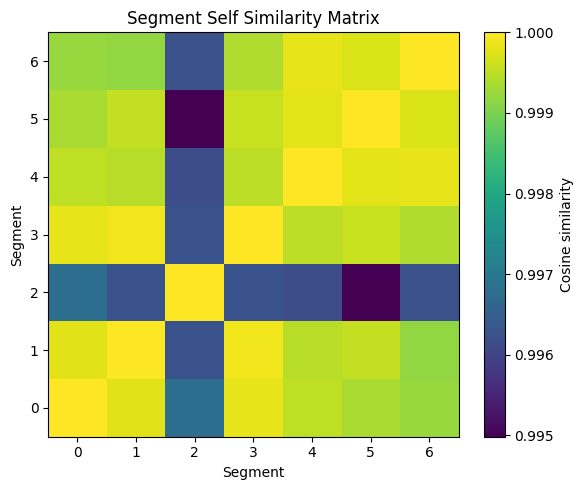

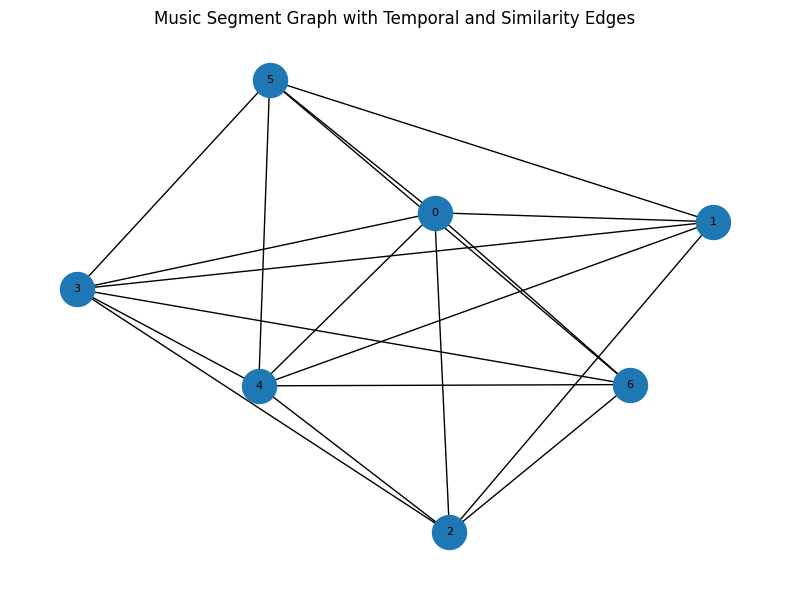

In [16]:
# CELL 16  Visualize one graph and its self similarity matrix

example_graph, example_similarity = (
    track_to_graph(example)
)

print("Number of nodes:", example_graph.num_nodes)
print("Number of directed edges:", example_graph.num_edges)
print(
    "Temporal directed edges:",
    int(
        (
            example_graph.edge_type
            == 0
        ).sum()
    ),
)
print(
    "Similarity directed edges:",
    int(
        (
            example_graph.edge_type
            == 1
        ).sum()
    ),
)
print(
    "Segmentation mode:",
    example_graph.segmentation_mode,
)

display_similarity = (
    example_similarity.copy()
)

np.fill_diagonal(
    display_similarity,
    1.0,
)

plt.figure(figsize=(6, 5))

plt.imshow(
    display_similarity,
    aspect="auto",
    origin="lower",
)

plt.colorbar(
    label="Cosine similarity"
)

plt.title(
    "Segment Self Similarity Matrix"
)

plt.xlabel("Segment")
plt.ylabel("Segment")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "example_self_similarity.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

network_graph = nx.Graph()

network_graph.add_nodes_from(
    range(example_graph.num_nodes)
)

for (
    source_node,
    destination_node,
), edge_type_value in zip(
    example_graph.edge_index.t().numpy(),
    example_graph.edge_type.numpy(),
):
    network_graph.add_edge(
        int(source_node),
        int(destination_node),
        edge_type=int(edge_type_value),
    )

positions = nx.spring_layout(
    network_graph,
    seed=SEED,
)

plt.figure(figsize=(8, 6))

nx.draw_networkx(
    network_graph,
    positions,
    node_size=600,
    font_size=8,
)

plt.title(
    "Music Segment Graph with Temporal and Similarity Edges"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "example_music_graph.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Precompute graph cache

The complete FMA small experiment builds one graph for every available track.

The raw graph cache is stored outside the GitHub folder so the final download stays small.

Only 24 representative graph examples are copied into the GitHub folder later.

In [17]:
# CELL 17  Select full experiment or development experiment

if FAST_DEV_RUN:
    pieces = []

    for split_name, number_of_rows in [
        ("training", DEV_TRAIN),
        ("validation", DEV_VALIDATION),
        ("test", DEV_TEST),
    ]:
        split_frame = meta[
            meta["split"] == split_name
        ]

        pieces.append(
            split_frame.sample(
                n=min(
                    number_of_rows,
                    len(split_frame),
                ),
                random_state=SEED,
            )
        )

    experiment_meta = (
        pd.concat(pieces)
        .reset_index(drop=True)
    )

else:
    experiment_meta = (
        meta.copy()
        .reset_index(drop=True)
    )

print(
    "Number of tracks in experiment:",
    len(experiment_meta),
)

display(
    experiment_meta[
        "split"
    ].value_counts()
)

Number of tracks in experiment: 8000


split
training      6400
validation     800
test           800
Name: count, dtype: int64

In [18]:
# CELL 18  Build and cache raw graphs

graph_failures = []
start_time = time.time()

for row_number, row in experiment_meta.iterrows():
    output_path = (
        RAW_GRAPH_DIR
        / f"{int(row['track_id']):06d}.pt"
    )

    if output_path.exists():
        continue

    try:
        graph, _ = track_to_graph(
            row
        )

        torch.save(
            graph,
            output_path,
        )

    except Exception as error:
        graph_failures.append({
            "track_id": int(
                row["track_id"]
            ),
            "error": repr(error),
        })

    if (
        row_number + 1
    ) % 250 == 0:
        print(
            "Processed",
            row_number + 1,
            "of",
            len(experiment_meta),
            "tracks",
        )

        print(
            "Cached graphs:",
            len(
                list(
                    RAW_GRAPH_DIR.glob(
                        "*.pt"
                    )
                )
            ),
        )

        print(
            "Graph build failures:",
            len(graph_failures),
        )

        print(
            "Elapsed minutes:",
            round(
                (
                    time.time()
                    - start_time
                )
                / 60,
                1,
            ),
        )

graph_failure_frame = pd.DataFrame(
    graph_failures,
    columns=[
        "track_id",
        "error",
    ],
)

graph_failure_frame.to_csv(
    METRICS_DIR
    / "graph_build_failures.csv",
    index=False,
)

print(
    "Total cached raw graphs:",
    len(
        list(
            RAW_GRAPH_DIR.glob(
                "*.pt"
            )
        )
    ),
)

print(
    "Total graph build failures:",
    len(graph_failure_frame),
)

Processed 250 of 8000 tracks
Cached graphs: 250
Graph build failures: 0
Elapsed minutes: 1.4


[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


Processed 500 of 8000 tracks
Cached graphs: 500
Graph build failures: 0
Elapsed minutes: 2.8
Processed 750 of 8000 tracks
Cached graphs: 750
Graph build failures: 0
Elapsed minutes: 4.1


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Processed 1000 of 8000 tracks
Cached graphs: 1000
Graph build failures: 0
Elapsed minutes: 5.5


...

Processed 4500 of 8000 tracks
Cached graphs: 4496
Graph build failures: 4
Elapsed minutes: 24.8
Processed 4750 of 8000 tracks
Cached graphs: 4745
Graph build failures: 5
Elapsed minutes: 26.1


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Processed 5000 of 8000 tracks
Cached graphs: 4994
Graph build failures: 6
Elapsed minutes: 27.5
Processed 5250 of 8000 tracks
Cached graphs: 5244
Graph build failures: 6
Elapsed minutes: 28.9
Processed 5500 of 8000 tracks
Cached graphs: 5494
Graph build failures: 6
Elapsed minutes: 30.3
Processed 5750 of 8000 tracks
Cached graphs: 5744
Graph build failures: 6
Elapsed minutes: 31.7
Processed 6000 of 8000 tracks
Cached graphs: 5994
Graph build failures: 6
Elapsed minutes: 33.1
Processed 6250 of 8000 tracks
Cached graphs: 6244
Graph build failures: 6
Elapsed minutes: 34.5
Processed 6500 of 8000 tracks
Cached graphs: 6494
Graph build failures: 6
Elapsed minutes: 35.9
Processed 6750 of 8000 tracks
Cached graphs: 6744
Graph build failures: 6
Elapsed minutes: 37.3


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Processed 7000 of 8000 tracks
Cached graphs: 6993
Graph build failures: 7
Elapsed minutes: 38.7
Processed 7250 of 8000 tracks
Cached graphs: 7243
Graph build failures: 7
Elapsed minutes: 40.1
Processed 7500 of 8000 tracks
Cached graphs: 7493
Graph build failures: 7
Elapsed minutes: 41.5
Processed 7750 of 8000 tracks
Cached graphs: 7743
Graph build failures: 7
Elapsed minutes: 42.8
Processed 8000 of 8000 tracks
Cached graphs: 7993
Graph build failures: 7
Elapsed minutes: 44.2
Total cached raw graphs: 7993
Total graph build failures: 7


In [19]:
# CELL 19  Graph integrity and density audit

audit_rows = []
bad_graph_rows = []

for path in sorted(
    RAW_GRAPH_DIR.glob("*.pt")
):
    try:
        graph = torch.load(
            path,
            weights_only=False,
        )

        problems = []

        if (
            graph.x.ndim != 2
            or graph.x.shape[1] != 228
        ):
            problems.append(
                f"node_feature_shape={tuple(graph.x.shape)}"
            )

        if not torch.isfinite(
            graph.x
        ).all():
            problems.append(
                "non_finite_node_features"
            )

        if (
            graph.edge_index.ndim != 2
            or graph.edge_index.shape[0] != 2
        ):
            problems.append(
                "invalid_edge_index_shape"
            )

        if (
            graph.edge_index.numel()
            and int(
                graph.edge_index.max()
            )
            >= graph.num_nodes
        ):
            problems.append(
                "edge_index_out_of_range"
            )

        temporal_edges = int(
            (
                graph.edge_type
                == 0
            ).sum()
        )

        similarity_edges = int(
            (
                graph.edge_type
                == 1
            ).sum()
        )

        audit_rows.append({
            "track_id": int(
                graph.track_id.item()
            ),
            "nodes": graph.num_nodes,
            "edges": graph.num_edges,
            "temporal_edges": temporal_edges,
            "similarity_edges": similarity_edges,
            "similarity_edges_per_node": (
                similarity_edges
                / max(
                    graph.num_nodes,
                    1,
                )
            ),
            "segmentation_mode": getattr(
                graph,
                "segmentation_mode",
                "unknown",
            ),
        })

        if problems:
            bad_graph_rows.append({
                "file": path.name,
                "problem": "; ".join(
                    problems
                ),
            })

    except Exception as error:
        bad_graph_rows.append({
            "file": path.name,
            "problem": repr(error),
        })

graph_audit_frame = pd.DataFrame(
    audit_rows
)

bad_graph_frame = pd.DataFrame(
    bad_graph_rows,
    columns=[
        "file",
        "problem",
    ],
)

graph_audit_frame.to_csv(
    METRICS_DIR / "graph_audit.csv",
    index=False,
)

bad_graph_frame.to_csv(
    METRICS_DIR / "bad_graphs.csv",
    index=False,
)

numeric_graph_audit = (
    graph_audit_frame
    .select_dtypes(
        include=[np.number]
    )
)

if (
    len(numeric_graph_audit.columns) > 0
    and len(numeric_graph_audit) > 0
):
    display(
        numeric_graph_audit.describe()
    )

print("Segmentation modes")

display(
    graph_audit_frame[
        "segmentation_mode"
    ].value_counts()
)

print(
    "Bad graphs:",
    len(bad_graph_frame),
)

mean_similarity_edges_per_node = float(
    graph_audit_frame[
        "similarity_edges_per_node"
    ].mean()
)

print(
    "Mean directed similarity edges per node:",
    round(
        mean_similarity_edges_per_node,
        3,
    ),
)

if (
    mean_similarity_edges_per_node
    < 1.0
):
    print(
        "Warning: the similarity graph is sparse."
    )
else:
    print(
        "Similarity structure is materially present in the graph."
    )

,track_id,nodes,edges,temporal_edges,similarity_edges,similarity_edges_per_node
count,7993.000000,7993.000000,7993.000000,7993.000000,7993.000000,7993.000000
mean,84107.290004,14.425873,85.654948,26.851745,58.803203,4.060694
std,43309.978544,3.496107,22.425330,6.992214,15.628073,0.309106
min,2.000000,6.000000,28.000000,10.000000,18.000000,3.000000
25%,49061.000000,12.000000,70.000000,22.000000,48.000000,3.846154
50%,89192.000000,14.000000,84.000000,26.000000,58.000000,4.000000
75%,122578.000000,17.000000,100.000000,32.000000,68.000000,4.272727
max,155066.000000,24.000000,156.000000,46.000000,110.000000,5.052632


Segmentation modes


segmentation_mode
beat_bar          7863
fixed_fallback     130
Name: count, dtype: int64

Bad graphs: 0
Mean directed similarity edges per node: 4.061
Similarity structure is materially present in the graph.


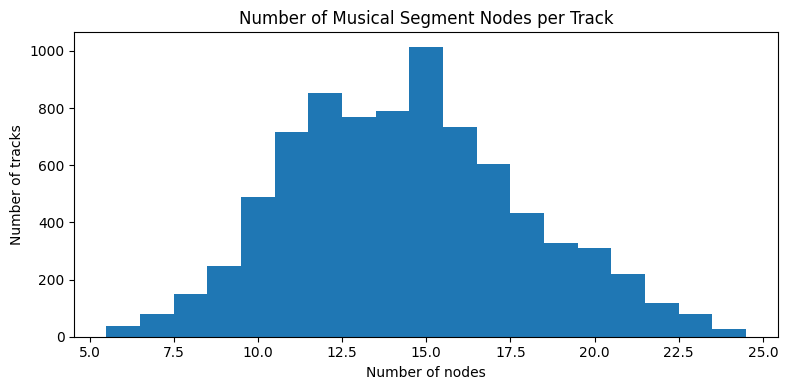

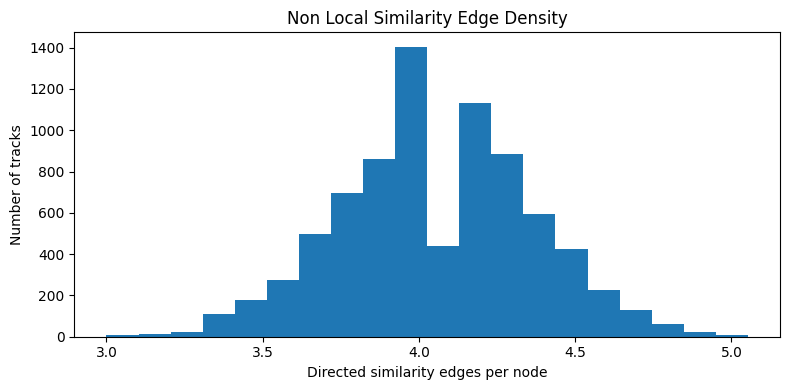

In [20]:
# CELL 20  Graph statistics plots

fig, axis = plt.subplots(
    figsize=(8, 4)
)

axis.hist(
    graph_audit_frame["nodes"],
    bins=(
        np.arange(
            graph_audit_frame["nodes"].min(),
            graph_audit_frame["nodes"].max() + 2,
        )
        - 0.5
    ),
)

axis.set_title(
    "Number of Musical Segment Nodes per Track"
)

axis.set_xlabel(
    "Number of nodes"
)

axis.set_ylabel(
    "Number of tracks"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "graph_node_distribution.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

fig, axis = plt.subplots(
    figsize=(8, 4)
)

axis.hist(
    graph_audit_frame[
        "similarity_edges_per_node"
    ],
    bins=20,
)

axis.set_title(
    "Non Local Similarity Edge Density"
)

axis.set_xlabel(
    "Directed similarity edges per node"
)

axis.set_ylabel(
    "Number of tracks"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "graph_similarity_density.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Training only feature normalization

Only valid cached graphs are kept.

The StandardScaler is fitted on training graph nodes only and then applied to training, validation, and test graphs.

This prevents validation and test information from leaking into preprocessing.

In [21]:
# CELL 21  Keep valid cached tracks

bad_names = (
    set(
        bad_graph_frame["file"]
    )
    if len(bad_graph_frame)
    else set()
)

available_track_ids = {
    int(path.stem)
    for path in RAW_GRAPH_DIR.glob(
        "*.pt"
    )
    if path.name not in bad_names
}

valid_meta = (
    experiment_meta[
        experiment_meta[
            "track_id"
        ].isin(
            available_track_ids
        )
    ]
    .copy()
    .reset_index(drop=True)
)

train_meta = (
    valid_meta[
        valid_meta["split"]
        == "training"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_meta = (
    valid_meta[
        valid_meta["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_meta = (
    valid_meta[
        valid_meta["split"]
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Valid training tracks:",
    len(train_meta),
)

print(
    "Valid validation tracks:",
    len(validation_meta),
)

print(
    "Valid test tracks:",
    len(test_meta),
)

Valid training tracks: 6393
Valid validation tracks: 800
Valid test tracks: 800


In [22]:
# CELL 22  Fit StandardScaler on training nodes only

node_scaler = StandardScaler()

for row_number, track_id in enumerate(
    train_meta[
        "track_id"
    ].astype(int)
):
    graph = torch.load(
        RAW_GRAPH_DIR
        / f"{track_id:06d}.pt",
        weights_only=False,
    )

    node_scaler.partial_fit(
        graph.x.numpy()
    )

    if (
        row_number + 1
    ) % 1000 == 0:
        print(
            "Scaler fitted on",
            row_number + 1,
            "training graphs",
        )

joblib.dump(
    node_scaler,
    PREPROCESSING_DIR
    / "training_node_scaler.joblib",
)

print(
    "Scaler feature dimensions:",
    len(node_scaler.mean_),
)

Scaler fitted on 1000 training graphs
Scaler fitted on 2000 training graphs
Scaler fitted on 3000 training graphs
Scaler fitted on 4000 training graphs
Scaler fitted on 5000 training graphs
Scaler fitted on 6000 training graphs
Scaler feature dimensions: 228


In [28]:
# CELL 23  Save training validation and test split files

for split_name, frame in [
    ("training", train_meta),
    ("validation", validation_meta),
    ("test", test_meta),
]:
    records = frame[
        [
            "track_id",
            "genre",
            "label",
            "artist_id",
        ]
    ].to_dict("records")

    with open(
        SPLIT_DIR
        / f"{split_name}.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            records,
            file,
            indent=2,
        )

print(
    "Split files saved in:",
    SPLIT_DIR,
)

Split files saved in: /kaggle/working/task2_fma_github/data_splits


In [29]:
# CELL 24  Scaled graph dataset and data loaders

class ScaledGraphDataset(
    torch.utils.data.Dataset
):
    def __init__(
        self,
        frame,
        graph_dir,
        scaler,
    ):
        self.frame = (
            frame
            .reset_index(drop=True)
        )

        self.graph_dir = Path(
            graph_dir
        )

        self.mean = torch.tensor(
            scaler.mean_,
            dtype=torch.float32,
        )

        self.scale = torch.tensor(
            scaler.scale_ + 1e-8,
            dtype=torch.float32,
        )

    def __len__(self):
        return len(self.frame)

    def __getitem__(
        self,
        index,
    ):
        track_id = int(
            self.frame.iloc[
                index
            ]["track_id"]
        )

        graph = torch.load(
            self.graph_dir
            / f"{track_id:06d}.pt",
            weights_only=False,
        )

        graph.x = (
            graph.x - self.mean
        ) / self.scale

        graph.x = torch.clamp(
            graph.x,
            -6.0,
            6.0,
        )

        return graph

train_graphs = ScaledGraphDataset(
    train_meta,
    RAW_GRAPH_DIR,
    node_scaler,
)

validation_graphs = ScaledGraphDataset(
    validation_meta,
    RAW_GRAPH_DIR,
    node_scaler,
)

test_graphs = ScaledGraphDataset(
    test_meta,
    RAW_GRAPH_DIR,
    node_scaler,
)

train_loader = GeoDataLoader(
    train_graphs,
    batch_size=BATCH_SIZE_GNN,
    shuffle=True,
)

validation_loader = GeoDataLoader(
    validation_graphs,
    batch_size=BATCH_SIZE_GNN,
    shuffle=False,
)

test_loader = GeoDataLoader(
    test_graphs,
    batch_size=BATCH_SIZE_GNN,
    shuffle=False,
)

example_batch = next(
    iter(train_loader)
)

print(
    "Batched node feature shape:",
    example_batch.x.shape,
)

print(
    "Number of graphs in example batch:",
    example_batch.num_graphs,
)

print(
    "Scaled node feature mean:",
    float(
        example_batch.x.mean()
    ),
)

print(
    "Scaled node feature standard deviation:",
    float(
        example_batch.x.std()
    ),
)

Batched node feature shape: torch.Size([705, 228])
Number of graphs in example batch: 48
Scaled node feature mean: -0.01999717205762863
Scaled node feature standard deviation: 1.0086361169815063


# GraphSAGE model

The GraphSAGE model uses two message passing layers.

Each layer aggregates neighboring graph nodes with mean aggregation.

Residual connections and layer normalization improve training stability.

Global mean pooling creates one representation for each music track.

The final classifier predicts one of eight FMA genres.

In [30]:
# CELL 25  Residual GraphSAGE model

class ResidualGraphSAGE(nn.Module):
    def __init__(
        self,
        input_dimension,
        hidden_dimension=GNN_HIDDEN,
        number_of_classes=8,
        dropout=GNN_DROPOUT,
        edge_dropout=GNN_EDGE_DROPOUT,
    ):
        super().__init__()

        self.dropout = dropout
        self.edge_dropout = edge_dropout

        self.input_projection = nn.Sequential(
            nn.Linear(
                input_dimension,
                hidden_dimension,
            ),
            nn.LayerNorm(
                hidden_dimension
            ),
            nn.GELU(),
        )

        self.convolution_1 = SAGEConv(
            hidden_dimension,
            hidden_dimension,
            aggr="mean",
        )

        self.convolution_2 = SAGEConv(
            hidden_dimension,
            hidden_dimension,
            aggr="mean",
        )

        self.normalization_1 = nn.LayerNorm(
            hidden_dimension
        )

        self.normalization_2 = nn.LayerNorm(
            hidden_dimension
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                hidden_dimension,
                96,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                96,
                number_of_classes,
            ),
        )

    def select_edges(
        self,
        data,
    ):
        edge_index = data.edge_index
        edge_type = data.edge_type

        if (
            self.training
            and self.edge_dropout > 0
        ):
            temporal_edges = (
                edge_type == 0
            )

            similarity_edges = (
                edge_type == 1
            )

            keep_similarity = (
                torch.rand(
                    edge_type.shape[0],
                    device=edge_type.device,
                )
                >= self.edge_dropout
            )

            keep = (
                temporal_edges
                | (
                    similarity_edges
                    & keep_similarity
                )
            )

            return edge_index[
                :,
                keep,
            ]

        return edge_index

    def encode_nodes(
        self,
        data,
    ):
        edge_index = self.select_edges(
            data
        )

        hidden = self.input_projection(
            data.x
        )

        hidden = F.dropout(
            hidden,
            p=0.08,
            training=self.training,
        )

        update = self.convolution_1(
            hidden,
            edge_index,
        )

        hidden = self.normalization_1(
            hidden
            + F.dropout(
                F.gelu(update),
                p=self.dropout,
                training=self.training,
            )
        )

        update = self.convolution_2(
            hidden,
            edge_index,
        )

        hidden = self.normalization_2(
            hidden
            + F.dropout(
                F.gelu(update),
                p=self.dropout,
                training=self.training,
            )
        )

        return hidden

    def encode_graph(
        self,
        data,
    ):
        node_embeddings = (
            self.encode_nodes(data)
        )

        return global_mean_pool(
            node_embeddings,
            data.batch,
        )

    def forward(
        self,
        data,
    ):
        graph_embedding = (
            self.encode_graph(data)
        )

        return self.classifier(
            graph_embedding
        )

NUMBER_OF_CLASSES = len(
    genres
)

graphsage_model = ResidualGraphSAGE(
    input_dimension=(
        example_batch.num_node_features
    ),
    hidden_dimension=GNN_HIDDEN,
    number_of_classes=(
        NUMBER_OF_CLASSES
    ),
).to(DEVICE)

print(graphsage_model)

print(
    "Trainable GraphSAGE parameters:",
    sum(
        parameter.numel()
        for parameter
        in graphsage_model.parameters()
        if parameter.requires_grad
    ),
)

ResidualGraphSAGE(
  (input_projection): Sequential(
    (0): Linear(in_features=228, out_features=192, bias=True)
    (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
  (convolution_1): SAGEConv(192, 192, aggr=mean)
  (convolution_2): SAGEConv(192, 192, aggr=mean)
  (normalization_1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (normalization_2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=96, out_features=8, bias=True)
  )
)
Trainable GraphSAGE parameters: 212264


In [31]:
# CELL 26  Classification metrics

def classification_metrics(
    true_labels,
    predicted_labels,
    probabilities,
):
    true_labels = np.asarray(
        true_labels
    )

    predicted_labels = np.asarray(
        predicted_labels
    )

    probabilities = np.asarray(
        probabilities
    )

    binary_true_labels = label_binarize(
        true_labels,
        classes=np.arange(
            NUMBER_OF_CLASSES
        ),
    )

    per_class_average_precision = (
        average_precision_score(
            binary_true_labels,
            probabilities,
            average=None,
        )
    )

    metrics = {
        "accuracy": accuracy_score(
            true_labels,
            predicted_labels,
        ),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
        ),
        "micro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="micro",
        ),
        "macro_area_under_precision_recall_curve": float(
            np.mean(
                per_class_average_precision
            )
        ),
    }

    return (
        metrics,
        per_class_average_precision,
    )

In [33]:
# CELL 27  Run one GraphSAGE training or evaluation Epoch

def run_graphsage_epoch(
    model,
    loader,
    optimizer=None,
):
    training = (
        optimizer is not None
    )

    model.train(training)

    total_loss = 0.0

    true_labels = []
    predicted_labels = []
    probabilities = []
    track_ids = []

    for batch in loader:
        batch = batch.to(
            DEVICE
        )

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        logits = model(
            batch
        )

        targets = batch.y.view(
            -1
        )

        loss = F.cross_entropy(
            logits,
            targets,
            label_smoothing=(
                LABEL_SMOOTHING
                if training
                else 0.0
            ),
        )

        if training:
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                2.0,
            )

            optimizer.step()

        batch_probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )
        )

        batch_predictions = (
            batch_probabilities.argmax(
                dim=1
            )
        )

        total_loss += (
            loss.item()
            * len(targets)
        )

        true_labels.extend(
            targets
            .detach()
            .cpu()
            .numpy()
        )

        predicted_labels.extend(
            batch_predictions
            .detach()
            .cpu()
            .numpy()
        )

        probabilities.extend(
            batch_probabilities
            .detach()
            .cpu()
            .numpy()
        )

        track_ids.extend(
            batch.track_id
            .view(-1)
            .detach()
            .cpu()
            .numpy()
        )

    true_labels = np.asarray(
        true_labels
    )

    predicted_labels = np.asarray(
        predicted_labels
    )

    probabilities = np.asarray(
        probabilities
    )

    metrics, per_class_average_precision = (
        classification_metrics(
            true_labels,
            predicted_labels,
            probabilities,
        )
    )

    metrics["loss"] = (
        total_loss
        / len(true_labels)
    )

    return (
        metrics,
        true_labels,
        predicted_labels,
        probabilities,
        np.asarray(track_ids),
        per_class_average_precision,
    )

# Train GraphSAGE

The model is selected using validation Macro F1 score.

The best parameters stay only in memory.

No GraphSAGE weight file is written to the final folder.

In [34]:
# CELL 28  Train GraphSAGE without saving model weights

graphsage_optimizer = torch.optim.AdamW(
    graphsage_model.parameters(),
    lr=LR_GNN,
    weight_decay=WEIGHT_DECAY,
)

graphsage_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        graphsage_optimizer,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    )
)

best_validation_macro_f1 = -1.0
best_graphsage_epoch = -1
epochs_without_improvement = 0
graphsage_history_rows = []
best_graphsage_state = None

for epoch in range(
    1,
    EPOCHS_GNN + 1,
):
    training_metrics, *_ = (
        run_graphsage_epoch(
            graphsage_model,
            train_loader,
            graphsage_optimizer,
        )
    )

    validation_metrics, *_ = (
        run_graphsage_epoch(
            graphsage_model,
            validation_loader,
        )
    )

    graphsage_scheduler.step(
        validation_metrics[
            "macro_f1"
        ]
    )

    current_learning_rate = (
        graphsage_optimizer
        .param_groups[0]["lr"]
    )

    graphsage_history_rows.append({
        "epoch": epoch,
        "learning_rate": current_learning_rate,
        "training_loss": training_metrics["loss"],
        "training_accuracy": training_metrics["accuracy"],
        "training_macro_f1_score": training_metrics["macro_f1"],
        "training_micro_f1_score": training_metrics["micro_f1"],
        "training_macro_area_under_precision_recall_curve": training_metrics[
            "macro_area_under_precision_recall_curve"
        ],
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1_score": validation_metrics["macro_f1"],
        "validation_micro_f1_score": validation_metrics["micro_f1"],
        "validation_macro_area_under_precision_recall_curve": validation_metrics[
            "macro_area_under_precision_recall_curve"
        ],
    })

    print()
    print(
        "Epoch",
        epoch,
        "of",
        EPOCHS_GNN,
    )

    print(
        "Training loss:",
        f"{training_metrics['loss']:.4f}",
    )

    print(
        "Training accuracy:",
        f"{training_metrics['accuracy']:.4f}",
    )

    print(
        "Training Macro F1 score:",
        f"{training_metrics['macro_f1']:.4f}",
    )

    print(
        "Validation loss:",
        f"{validation_metrics['loss']:.4f}",
    )

    print(
        "Validation accuracy:",
        f"{validation_metrics['accuracy']:.4f}",
    )

    print(
        "Validation Macro F1 score:",
        f"{validation_metrics['macro_f1']:.4f}",
    )

    print(
        "Validation Macro Area Under the Precision Recall Curve:",
        f"{validation_metrics['macro_area_under_precision_recall_curve']:.4f}",
    )

    if (
        validation_metrics["macro_f1"]
        > best_validation_macro_f1
        + 1e-5
    ):
        best_validation_macro_f1 = (
            validation_metrics[
                "macro_f1"
            ]
        )

        best_graphsage_epoch = (
            epoch
        )

        epochs_without_improvement = 0

        best_graphsage_state = {
            name: value
            .detach()
            .cpu()
            .clone()
            for name, value
            in graphsage_model
            .state_dict()
            .items()
        }

        print(
            "Best GraphSAGE model in memory updated."
        )

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print(
            "GraphSAGE early stopping triggered."
        )
        break

graphsage_history = pd.DataFrame(
    graphsage_history_rows
)

graphsage_history.to_csv(
    METRICS_DIR
    / "graphsage_training_history.csv",
    index=False,
)

if best_graphsage_state is None:
    raise RuntimeError(
        "No GraphSAGE state was recorded."
    )

graphsage_model.load_state_dict(
    best_graphsage_state
)

graphsage_model.eval()

print()
print(
    "Best GraphSAGE Epoch:",
    best_graphsage_epoch,
)

print(
    "Best validation Macro F1 score:",
    f"{best_validation_macro_f1:.4f}",
)


Epoch 1 of 50
Training loss: 1.5880
Training accuracy: 0.4424
Training Macro F1 score: 0.4222
Validation loss: 1.3587
Validation accuracy: 0.5188
Validation Macro F1 score: 0.5082
Validation Macro Area Under the Precision Recall Curve: 0.5250
Best GraphSAGE model in memory updated.

Epoch 2 of 50
Training loss: 1.3662
Training accuracy: 0.5497
Training Macro F1 score: 0.5418
Validation loss: 1.3923
Validation accuracy: 0.5038
Validation Macro F1 score: 0.4886
Validation Macro Area Under the Precision Recall Curve: 0.5185

Epoch 3 of 50
Training loss: 1.2752
Training accuracy: 0.5869
Training Macro F1 score: 0.5811
Validation loss: 1.3921
Validation accuracy: 0.5250
Validation Macro F1 score: 0.5266
Validation Macro Area Under the Precision Recall Curve: 0.5402
Best GraphSAGE model in memory updated.

Epoch 4 of 50
Training loss: 1.2184
Training accuracy: 0.6130
Training Macro F1 score: 0.6091
Validation loss: 1.4085
Validation accuracy: 0.5100
Validation Macro F1 score: 0.5041
Validat

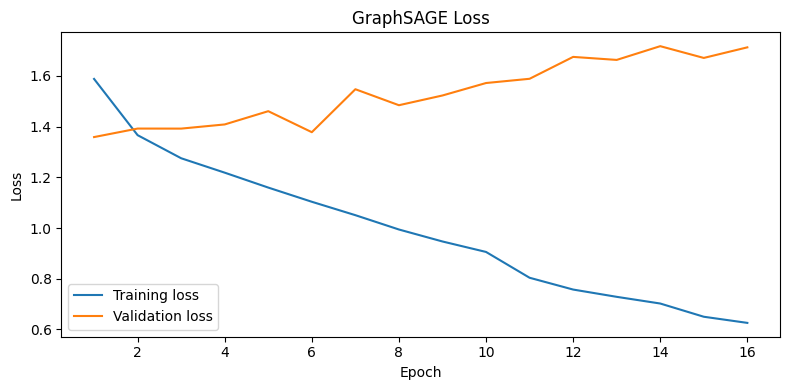

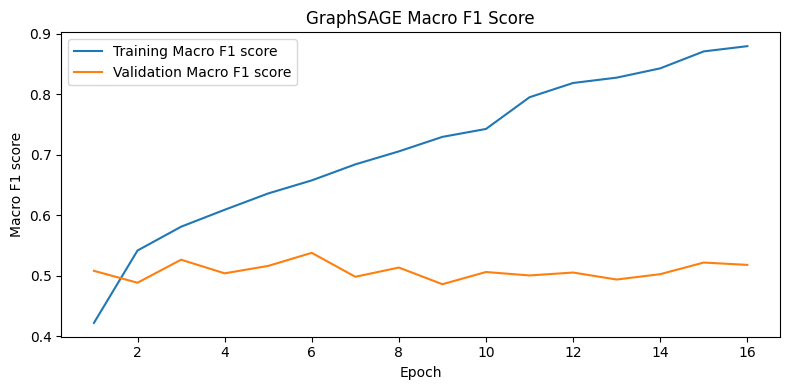

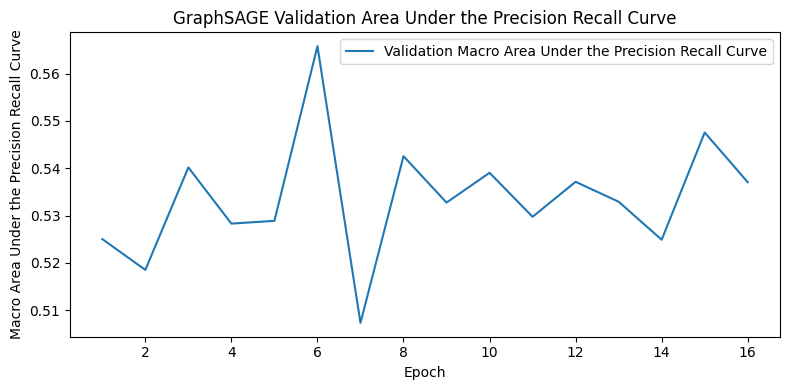

In [35]:
# CELL 29  GraphSAGE training curves

plt.figure(figsize=(8, 4))

plt.plot(
    graphsage_history["epoch"],
    graphsage_history["training_loss"],
    label="Training loss",
)

plt.plot(
    graphsage_history["epoch"],
    graphsage_history["validation_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "graphsage_loss.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    graphsage_history["epoch"],
    graphsage_history[
        "training_macro_f1_score"
    ],
    label="Training Macro F1 score",
)

plt.plot(
    graphsage_history["epoch"],
    graphsage_history[
        "validation_macro_f1_score"
    ],
    label="Validation Macro F1 score",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 score")
plt.title("GraphSAGE Macro F1 Score")
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "graphsage_macro_f1_score.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    graphsage_history["epoch"],
    graphsage_history[
        "validation_macro_area_under_precision_recall_curve"
    ],
    label="Validation Macro Area Under the Precision Recall Curve",
)

plt.xlabel("Epoch")
plt.ylabel(
    "Macro Area Under the Precision Recall Curve"
)
plt.title(
    "GraphSAGE Validation Area Under the Precision Recall Curve"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "graphsage_validation_precision_recall_area.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [36]:
# CELL 30  Final GraphSAGE test evaluation

(
    graphsage_test_metrics,
    graphsage_true_labels,
    graphsage_predicted_labels,
    graphsage_probabilities,
    graphsage_track_ids,
    graphsage_per_class_average_precision,
) = run_graphsage_epoch(
    graphsage_model,
    test_loader,
)

print("GraphSAGE test results")

print(
    "Accuracy:",
    f"{graphsage_test_metrics['accuracy']:.4f}",
)

print(
    "Macro F1 score:",
    f"{graphsage_test_metrics['macro_f1']:.4f}",
)

print(
    "Micro F1 score:",
    f"{graphsage_test_metrics['micro_f1']:.4f}",
)

print(
    "Macro Area Under the Precision Recall Curve:",
    f"{graphsage_test_metrics['macro_area_under_precision_recall_curve']:.4f}",
)

print(
    "Test loss:",
    f"{graphsage_test_metrics['loss']:.4f}",
)

graphsage_classification_report = pd.DataFrame(
    classification_report(
        graphsage_true_labels,
        graphsage_predicted_labels,
        target_names=[
            index_to_genre[index]
            for index in range(
                NUMBER_OF_CLASSES
            )
        ],
        output_dict=True,
        digits=4,
    )
).T

display(
    graphsage_classification_report
)

graphsage_classification_report.to_csv(
    METRICS_DIR
    / "graphsage_classification_report.csv"
)

graphsage_per_class_table = pd.DataFrame({
    "genre": [
        index_to_genre[index]
        for index in range(
            NUMBER_OF_CLASSES
        )
    ],
    "average_precision": (
        graphsage_per_class_average_precision
    ),
})

graphsage_per_class_table.to_csv(
    METRICS_DIR
    / "graphsage_per_class_average_precision.csv",
    index=False,
)

graphsage_prediction_frame = pd.DataFrame({
    "track_id": graphsage_track_ids,
    "true_label": graphsage_true_labels,
    "predicted_label": graphsage_predicted_labels,
    "true_genre": [
        index_to_genre[
            int(index)
        ]
        for index
        in graphsage_true_labels
    ],
    "predicted_genre": [
        index_to_genre[
            int(index)
        ]
        for index
        in graphsage_predicted_labels
    ],
    "prediction_confidence": (
        graphsage_probabilities.max(
            axis=1
        )
    ),
})

graphsage_prediction_frame.to_csv(
    METRICS_DIR
    / "graphsage_test_predictions.csv",
    index=False,
)

GraphSAGE test results
Accuracy: 0.4838
Macro F1 score: 0.4805
Micro F1 score: 0.4838
Macro Area Under the Precision Recall Curve: 0.4997
Test loss: 1.5525


,precision,recall,f1-score,support
Electronic,0.507812,0.65000,0.570175,100.00000
Experimental,0.303704,0.41000,0.348936,100.00000
Folk,0.239437,0.17000,0.198830,100.00000
Hip-Hop,0.752688,0.70000,0.725389,100.00000
Instrumental,0.378049,0.31000,0.340659,100.00000
International,0.584906,0.62000,0.601942,100.00000
Pop,0.420000,0.42000,0.420000,100.00000
Rock,0.694118,0.59000,0.637838,100.00000
accuracy,0.483750,0.48375,0.483750,0.48375
macro avg,0.485089,0.48375,0.480471,800.00000


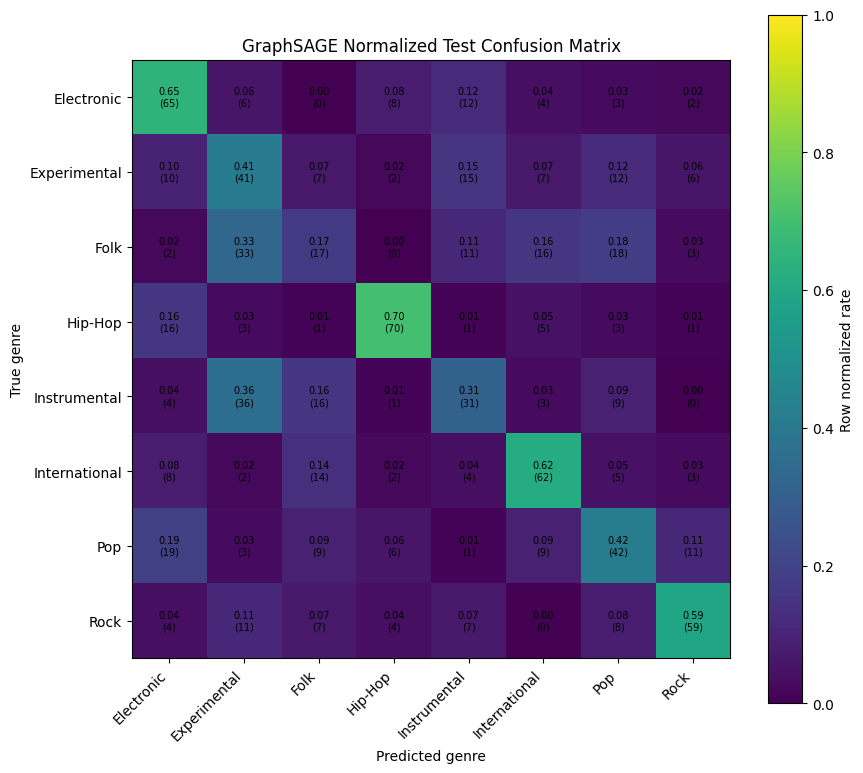

In [37]:
# CELL 31  GraphSAGE confusion matrix

confusion = confusion_matrix(
    graphsage_true_labels,
    graphsage_predicted_labels,
)

normalized_confusion = (
    confusion
    / np.maximum(
        confusion.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
)

figure, axis = plt.subplots(
    figsize=(9, 8)
)

image = axis.imshow(
    normalized_confusion,
    vmin=0,
    vmax=1,
)

figure.colorbar(
    image,
    ax=axis,
    label="Row normalized rate",
)

axis.set_xticks(
    range(NUMBER_OF_CLASSES)
)

axis.set_yticks(
    range(NUMBER_OF_CLASSES)
)

axis.set_xticklabels(
    genres,
    rotation=45,
    ha="right",
)

axis.set_yticklabels(
    genres
)

axis.set_xlabel(
    "Predicted genre"
)

axis.set_ylabel(
    "True genre"
)

axis.set_title(
    "GraphSAGE Normalized Test Confusion Matrix"
)

for row in range(
    NUMBER_OF_CLASSES
):
    for column in range(
        NUMBER_OF_CLASSES
    ):
        axis.text(
            column,
            row,
            (
                f"{normalized_confusion[row, column]:.2f}"
                f"\n({confusion[row, column]})"
            ),
            ha="center",
            va="center",
            fontsize=7,
        )

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "graphsage_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

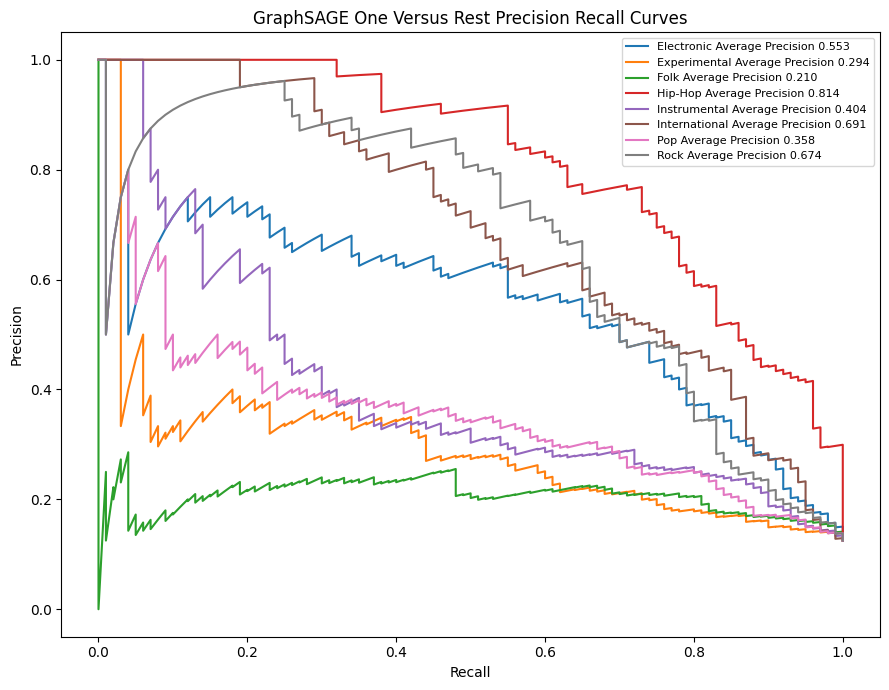

In [38]:
# CELL 32  GraphSAGE precision recall curves

binary_test_labels = label_binarize(
    graphsage_true_labels,
    classes=np.arange(
        NUMBER_OF_CLASSES
    ),
)

plt.figure(figsize=(9, 7))

for class_index in range(
    NUMBER_OF_CLASSES
):
    precision, recall, _ = (
        precision_recall_curve(
            binary_test_labels[
                :,
                class_index,
            ],
            graphsage_probabilities[
                :,
                class_index,
            ],
        )
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{index_to_genre[class_index]} "
            f"Average Precision "
            f"{graphsage_per_class_average_precision[class_index]:.3f}"
        ),
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "GraphSAGE One Versus Rest Precision Recall Curves"
)

plt.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "graphsage_precision_recall_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Majority class baseline

The majority predictor always predicts the most frequent training genre.

It is a simple sanity baseline.

In [39]:
# CELL 33  Majority class baseline

majority_label = int(
    train_meta[
        "label"
    ]
    .value_counts()
    .idxmax()
)

majority_predictions = np.full(
    len(graphsage_true_labels),
    majority_label,
)

majority_probabilities = np.full(
    (
        len(graphsage_true_labels),
        NUMBER_OF_CLASSES,
    ),
    1.0 / NUMBER_OF_CLASSES,
    dtype=np.float32,
)

majority_metrics, _ = (
    classification_metrics(
        graphsage_true_labels,
        majority_predictions,
        majority_probabilities,
    )
)

print(
    "Majority genre:",
    index_to_genre[
        majority_label
    ],
)

print(
    "Majority accuracy:",
    f"{majority_metrics['accuracy']:.4f}",
)

print(
    "Majority Macro F1 score:",
    f"{majority_metrics['macro_f1']:.4f}",
)

print(
    "Majority Micro F1 score:",
    f"{majority_metrics['micro_f1']:.4f}",
)

print(
    "Majority Macro Area Under the Precision Recall Curve:",
    f"{majority_metrics['macro_area_under_precision_recall_curve']:.4f}",
)

Majority genre: Pop
Majority accuracy: 0.1250
Majority Macro F1 score: 0.0278
Majority Micro F1 score: 0.1250
Majority Macro Area Under the Precision Recall Curve: 0.1250


# Convolutional neural network baseline

The convolutional neural network uses a 128 bin log mel spectrogram from the same FMA audio.

This baseline does not use graphs.

The comparison therefore tests whether GraphSAGE adds useful structural information beyond a conventional spectrogram model.

In [40]:
# CELL 34  Cache convolutional neural network log mel arrays

def make_cnn_mel(
    path,
    track_id,
):
    audio = safe_load_audio(
        path,
        track_id,
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=1024,
        hop_length=320,
        n_mels=CNN_N_MELS,
        power=2.0,
    )

    decibels = librosa.power_to_db(
        mel,
        ref=1.0,
    ).astype(np.float32)

    decibels = np.clip(
        decibels,
        -100,
        20,
    )

    tensor = torch.from_numpy(
        decibels
    )[None, None, ...]

    tensor = F.interpolate(
        tensor,
        size=(
            CNN_N_MELS,
            CNN_IMAGE_TIME,
        ),
        mode="bilinear",
        align_corners=False,
    )

    return (
        tensor[0, 0]
        .numpy()
        .astype(np.float16)
    )

mel_failures = []

for row_number, row in valid_meta.iterrows():
    track_id = int(
        row["track_id"]
    )

    output_path = (
        MEL_DIR
        / f"{track_id:06d}.npy"
    )

    if output_path.exists():
        continue

    try:
        np.save(
            output_path,
            make_cnn_mel(
                row["audio_path"],
                track_id,
            ),
        )

    except Exception as error:
        mel_failures.append({
            "track_id": track_id,
            "error": repr(error),
        })

    if (
        row_number + 1
    ) % 500 == 0:
        print(
            "Processed",
            row_number + 1,
            "of",
            len(valid_meta),
            "tracks for the convolutional neural network baseline",
        )

mel_failure_frame = pd.DataFrame(
    mel_failures,
    columns=[
        "track_id",
        "error",
    ],
)

mel_failure_frame.to_csv(
    METRICS_DIR
    / "mel_build_failures.csv",
    index=False,
)

print(
    "Cached log mel files:",
    len(
        list(
            MEL_DIR.glob(
                "*.npy"
            )
        )
    ),
)

print(
    "Log mel failures:",
    len(mel_failure_frame),
)

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


Processed 500 of 7993 tracks for the convolutional neural network baseline


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Processed 1000 of 7993 tracks for the convolutional neural network baseline


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Processed 1500 of 7993 tracks for the convolutional neural network baseline
Processed 2000 of 7993 tracks for the convolutional neural network baseline


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)


Processed 2500 of 7993 tracks for the convolutional neural network baseline
Processed 3000 of 7993 tracks for the convolutional neural network baseline
Processed 3500 of 7993 tracks for the convolutional neural network baseline
Processed 4000 of 7993 tracks for the convolutional neural network baseline
Processed 4500 of 7993 tracks for the convolutional neural network baseline
Processed 5000 of 7993 tracks for the convolutional neural network baseline
Processed 5500 of 7993 tracks for the convolutional neural network baseline
Processed 6000 of 7993 tracks for the convolutional neural network baseline
Processed 6500 of 7993 tracks for the convolutional neural network baseline
Processed 7000 of 7993 tracks for the convolutional neural network baseline
Processed 7500 of 7993 tracks for the convolutional neural network baseline
Cached log mel files: 7993
Log mel failures: 0


In [41]:
# CELL 35  Log mel dataset and data loaders

class MelDataset(TorchDataset):
    def __init__(
        self,
        frame,
        mel_dir,
        training=False,
    ):
        self.frame = (
            frame
            .reset_index(drop=True)
        )

        self.mel_dir = Path(
            mel_dir
        )

        self.training = training

    def __len__(self):
        return len(self.frame)

    def __getitem__(
        self,
        index,
    ):
        row = self.frame.iloc[
            index
        ]

        track_id = int(
            row["track_id"]
        )

        image = torch.from_numpy(
            np.load(
                self.mel_dir
                / f"{track_id:06d}.npy"
            ).astype(np.float32)
        ).unsqueeze(0)

        image = (
            image + 60.0
        ) / 30.0

        image = torch.clamp(
            image,
            -2.0,
            2.0,
        )

        if self.training:
            if torch.rand(()) < 0.5:
                frequency_width = int(
                    torch.randint(
                        0,
                        10,
                        (1,),
                    )
                )

                if frequency_width > 0:
                    start_frequency = int(
                        torch.randint(
                            0,
                            CNN_N_MELS
                            - frequency_width
                            + 1,
                            (1,),
                        )
                    )

                    image[
                        :,
                        start_frequency:
                        start_frequency
                        + frequency_width,
                        :,
                    ] = 0

            if torch.rand(()) < 0.5:
                time_width = int(
                    torch.randint(
                        0,
                        20,
                        (1,),
                    )
                )

                if time_width > 0:
                    start_time = int(
                        torch.randint(
                            0,
                            CNN_IMAGE_TIME
                            - time_width
                            + 1,
                            (1,),
                        )
                    )

                    image[
                        :,
                        :,
                        start_time:
                        start_time
                        + time_width,
                    ] = 0

        return (
            image,
            torch.tensor(
                int(row["label"]),
                dtype=torch.long,
            ),
            torch.tensor(
                track_id,
                dtype=torch.long,
            ),
        )

train_mels = MelDataset(
    train_meta,
    MEL_DIR,
    training=True,
)

validation_mels = MelDataset(
    validation_meta,
    MEL_DIR,
    training=False,
)

test_mels = MelDataset(
    test_meta,
    MEL_DIR,
    training=False,
)

train_mel_loader = TorchDataLoader(
    train_mels,
    batch_size=BATCH_SIZE_CNN,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

validation_mel_loader = TorchDataLoader(
    validation_mels,
    batch_size=BATCH_SIZE_CNN,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_mel_loader = TorchDataLoader(
    test_mels,
    batch_size=BATCH_SIZE_CNN,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

example_images, example_labels, _ = next(
    iter(train_mel_loader)
)

print(
    "Convolutional neural network input shape:",
    example_images.shape,
)

print(
    "Example label shape:",
    example_labels.shape,
)

Convolutional neural network input shape: torch.Size([48, 1, 128, 256])
Example label shape: torch.Size([48])


In [42]:
# CELL 36  Residual convolutional neural network baseline

class ResidualBlock(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        stride=1,
    ):
        super().__init__()

        self.convolution_1 = nn.Conv2d(
            input_channels,
            output_channels,
            3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.batch_normalization_1 = nn.BatchNorm2d(
            output_channels
        )

        self.convolution_2 = nn.Conv2d(
            output_channels,
            output_channels,
            3,
            padding=1,
            bias=False,
        )

        self.batch_normalization_2 = nn.BatchNorm2d(
            output_channels
        )

        if (
            input_channels == output_channels
            and stride == 1
        ):
            self.skip = nn.Identity()
        else:
            self.skip = nn.Sequential(
                nn.Conv2d(
                    input_channels,
                    output_channels,
                    1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(
                    output_channels
                ),
            )

    def forward(
        self,
        inputs,
    ):
        residual = self.skip(
            inputs
        )

        outputs = F.relu(
            self.batch_normalization_1(
                self.convolution_1(
                    inputs
                )
            )
        )

        outputs = (
            self.batch_normalization_2(
                self.convolution_2(
                    outputs
                )
            )
        )

        return F.relu(
            outputs + residual
        )

class MelResidualCNN(nn.Module):
    def __init__(
        self,
        number_of_classes,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                5,
                stride=2,
                padding=2,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        self.body = nn.Sequential(
            ResidualBlock(
                32,
                64,
                2,
            ),
            ResidualBlock(
                64,
                96,
                2,
            ),
            ResidualBlock(
                96,
                128,
                2,
            ),
            ResidualBlock(
                128,
                192,
                2,
            ),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(
                192,
                number_of_classes,
            ),
        )

    def forward(
        self,
        inputs,
    ):
        return self.classifier(
            self.body(
                self.stem(
                    inputs
                )
            )
        )

cnn_model = MelResidualCNN(
    NUMBER_OF_CLASSES
).to(DEVICE)

print(cnn_model)

print(
    "Trainable convolutional neural network parameters:",
    sum(
        parameter.numel()
        for parameter
        in cnn_model.parameters()
        if parameter.requires_grad
    ),
)

MelResidualCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (body): Sequential(
    (0): ResidualBlock(
      (convolution_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (batch_normalization_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (convolution_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_normalization_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (convolution_1): Conv2d(64, 96, kernel_size=(3, 3), stride=

In [43]:
# CELL 37  Run one convolutional neural network training or evaluation Epoch

def run_cnn_epoch(
    model,
    loader,
    optimizer=None,
):
    training = (
        optimizer is not None
    )

    model.train(training)

    total_loss = 0.0

    true_labels = []
    predicted_labels = []
    probabilities = []
    track_ids = []

    for images, labels, track_id in loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        logits = model(
            images
        )

        loss = F.cross_entropy(
            logits,
            labels,
            label_smoothing=(
                LABEL_SMOOTHING
                if training
                else 0.0
            ),
        )

        if training:
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                2.0,
            )

            optimizer.step()

        batch_probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )
        )

        batch_predictions = (
            batch_probabilities.argmax(
                dim=1
            )
        )

        total_loss += (
            loss.item()
            * len(labels)
        )

        true_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        predicted_labels.extend(
            batch_predictions
            .detach()
            .cpu()
            .numpy()
        )

        probabilities.extend(
            batch_probabilities
            .detach()
            .cpu()
            .numpy()
        )

        track_ids.extend(
            track_id.numpy()
        )

    true_labels = np.asarray(
        true_labels
    )

    predicted_labels = np.asarray(
        predicted_labels
    )

    probabilities = np.asarray(
        probabilities
    )

    metrics, per_class_average_precision = (
        classification_metrics(
            true_labels,
            predicted_labels,
            probabilities,
        )
    )

    metrics["loss"] = (
        total_loss
        / len(true_labels)
    )

    return (
        metrics,
        true_labels,
        predicted_labels,
        probabilities,
        np.asarray(track_ids),
        per_class_average_precision,
    )

# Train the convolutional neural network baseline

The baseline is selected using validation Macro F1 score.

The best parameters stay only in memory.

No convolutional neural network weight file is written to the final folder.

In [44]:
# CELL 38  Train convolutional neural network without saving model weights

cnn_optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=LR_CNN,
    weight_decay=WEIGHT_DECAY,
)

cnn_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        cnn_optimizer,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    )
)

best_cnn_validation_macro_f1 = -1.0
best_cnn_epoch = -1
cnn_epochs_without_improvement = 0
cnn_history_rows = []
best_cnn_state = None

for epoch in range(
    1,
    EPOCHS_CNN + 1,
):
    training_metrics, *_ = (
        run_cnn_epoch(
            cnn_model,
            train_mel_loader,
            cnn_optimizer,
        )
    )

    validation_metrics, *_ = (
        run_cnn_epoch(
            cnn_model,
            validation_mel_loader,
        )
    )

    cnn_scheduler.step(
        validation_metrics[
            "macro_f1"
        ]
    )

    cnn_history_rows.append({
        "epoch": epoch,
        "training_loss": training_metrics["loss"],
        "training_accuracy": training_metrics["accuracy"],
        "training_macro_f1_score": training_metrics["macro_f1"],
        "training_micro_f1_score": training_metrics["micro_f1"],
        "training_macro_area_under_precision_recall_curve": training_metrics[
            "macro_area_under_precision_recall_curve"
        ],
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1_score": validation_metrics["macro_f1"],
        "validation_micro_f1_score": validation_metrics["micro_f1"],
        "validation_macro_area_under_precision_recall_curve": validation_metrics[
            "macro_area_under_precision_recall_curve"
        ],
    })

    print()
    print(
        "Epoch",
        epoch,
        "of",
        EPOCHS_CNN,
    )

    print(
        "Training loss:",
        f"{training_metrics['loss']:.4f}",
    )

    print(
        "Training accuracy:",
        f"{training_metrics['accuracy']:.4f}",
    )

    print(
        "Training Macro F1 score:",
        f"{training_metrics['macro_f1']:.4f}",
    )

    print(
        "Validation loss:",
        f"{validation_metrics['loss']:.4f}",
    )

    print(
        "Validation accuracy:",
        f"{validation_metrics['accuracy']:.4f}",
    )

    print(
        "Validation Macro F1 score:",
        f"{validation_metrics['macro_f1']:.4f}",
    )

    print(
        "Validation Macro Area Under the Precision Recall Curve:",
        f"{validation_metrics['macro_area_under_precision_recall_curve']:.4f}",
    )

    if (
        validation_metrics["macro_f1"]
        > best_cnn_validation_macro_f1
        + 1e-5
    ):
        best_cnn_validation_macro_f1 = (
            validation_metrics[
                "macro_f1"
            ]
        )

        best_cnn_epoch = epoch

        cnn_epochs_without_improvement = 0

        best_cnn_state = {
            name: value
            .detach()
            .cpu()
            .clone()
            for name, value
            in cnn_model
            .state_dict()
            .items()
        }

        print(
            "Best convolutional neural network model in memory updated."
        )

    else:
        cnn_epochs_without_improvement += 1

    if (
        cnn_epochs_without_improvement
        >= PATIENCE
    ):
        print(
            "Convolutional neural network early stopping triggered."
        )
        break

cnn_history = pd.DataFrame(
    cnn_history_rows
)

cnn_history.to_csv(
    METRICS_DIR
    / "cnn_training_history.csv",
    index=False,
)

if best_cnn_state is None:
    raise RuntimeError(
        "No convolutional neural network state was recorded."
    )

cnn_model.load_state_dict(
    best_cnn_state
)

cnn_model.eval()

print()
print(
    "Best convolutional neural network Epoch:",
    best_cnn_epoch,
)

print(
    "Best validation Macro F1 score:",
    f"{best_cnn_validation_macro_f1:.4f}",
)


Epoch 1 of 35
Training loss: 1.7479
Training accuracy: 0.3681
Training Macro F1 score: 0.3552
Validation loss: 1.6625
Validation accuracy: 0.3762
Validation Macro F1 score: 0.3468
Validation Macro Area Under the Precision Recall Curve: 0.4235
Best convolutional neural network model in memory updated.

Epoch 2 of 35
Training loss: 1.5849
Training accuracy: 0.4552
Training Macro F1 score: 0.4441
Validation loss: 2.2188
Validation accuracy: 0.3325
Validation Macro F1 score: 0.2689
Validation Macro Area Under the Precision Recall Curve: 0.3819

Epoch 3 of 35
Training loss: 1.5102
Training accuracy: 0.4927
Training Macro F1 score: 0.4843
Validation loss: 1.8172
Validation accuracy: 0.3563
Validation Macro F1 score: 0.3293
Validation Macro Area Under the Precision Recall Curve: 0.4014

Epoch 4 of 35
Training loss: 1.4528
Training accuracy: 0.5196
Training Macro F1 score: 0.5121
Validation loss: 2.9046
Validation accuracy: 0.2412
Validation Macro F1 score: 0.2139
Validation Macro Area Under 

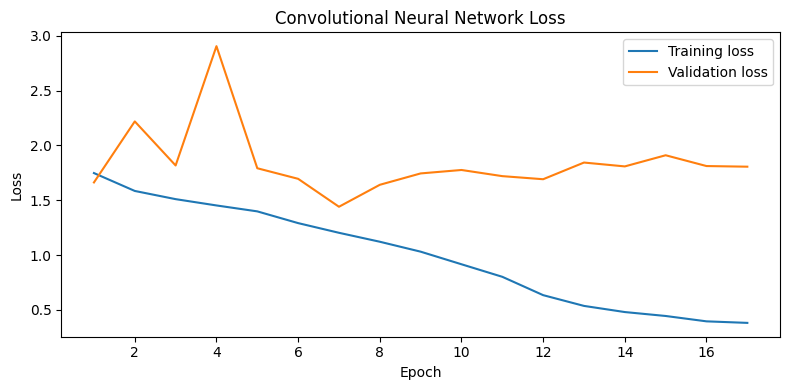

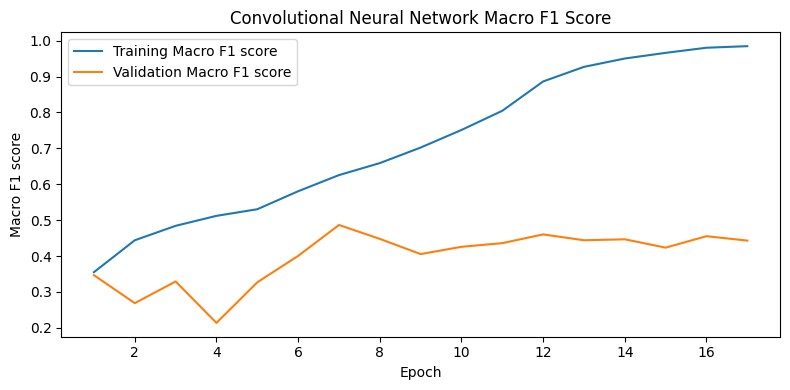

In [45]:
# CELL 39  Convolutional neural network training curves

plt.figure(figsize=(8, 4))

plt.plot(
    cnn_history["epoch"],
    cnn_history["training_loss"],
    label="Training loss",
)

plt.plot(
    cnn_history["epoch"],
    cnn_history["validation_loss"],
    label="Validation loss",
)

plt.title(
    "Convolutional Neural Network Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "cnn_loss.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    cnn_history["epoch"],
    cnn_history[
        "training_macro_f1_score"
    ],
    label="Training Macro F1 score",
)

plt.plot(
    cnn_history["epoch"],
    cnn_history[
        "validation_macro_f1_score"
    ],
    label="Validation Macro F1 score",
)

plt.title(
    "Convolutional Neural Network Macro F1 Score"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 score")
plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "cnn_macro_f1_score.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [46]:
# CELL 40  Final convolutional neural network test evaluation

(
    cnn_test_metrics,
    cnn_true_labels,
    cnn_predicted_labels,
    cnn_probabilities,
    cnn_track_ids,
    cnn_per_class_average_precision,
) = run_cnn_epoch(
    cnn_model,
    test_mel_loader,
)

print(
    "Convolutional neural network test results"
)

print(
    "Accuracy:",
    f"{cnn_test_metrics['accuracy']:.4f}",
)

print(
    "Macro F1 score:",
    f"{cnn_test_metrics['macro_f1']:.4f}",
)

print(
    "Micro F1 score:",
    f"{cnn_test_metrics['micro_f1']:.4f}",
)

print(
    "Macro Area Under the Precision Recall Curve:",
    f"{cnn_test_metrics['macro_area_under_precision_recall_curve']:.4f}",
)

print(
    "Test loss:",
    f"{cnn_test_metrics['loss']:.4f}",
)

cnn_classification_report = pd.DataFrame(
    classification_report(
        cnn_true_labels,
        cnn_predicted_labels,
        target_names=genres,
        output_dict=True,
        digits=4,
    )
).T

display(
    cnn_classification_report
)

cnn_classification_report.to_csv(
    METRICS_DIR
    / "cnn_classification_report.csv"
)

Convolutional neural network test results
Accuracy: 0.4213
Macro F1 score: 0.4210
Micro F1 score: 0.4213
Macro Area Under the Precision Recall Curve: 0.4319
Test loss: 1.6487


,precision,recall,f1-score,support
Electronic,0.525000,0.42000,0.466667,100.00000
Experimental,0.279661,0.33000,0.302752,100.00000
Folk,0.290698,0.25000,0.268817,100.00000
Hip-Hop,0.629630,0.68000,0.653846,100.00000
Instrumental,0.378378,0.56000,0.451613,100.00000
International,0.542857,0.38000,0.447059,100.00000
Pop,0.274510,0.28000,0.277228,100.00000
Rock,0.534091,0.47000,0.500000,100.00000
accuracy,0.421250,0.42125,0.421250,0.42125
macro avg,0.431853,0.42125,0.420998,800.00000


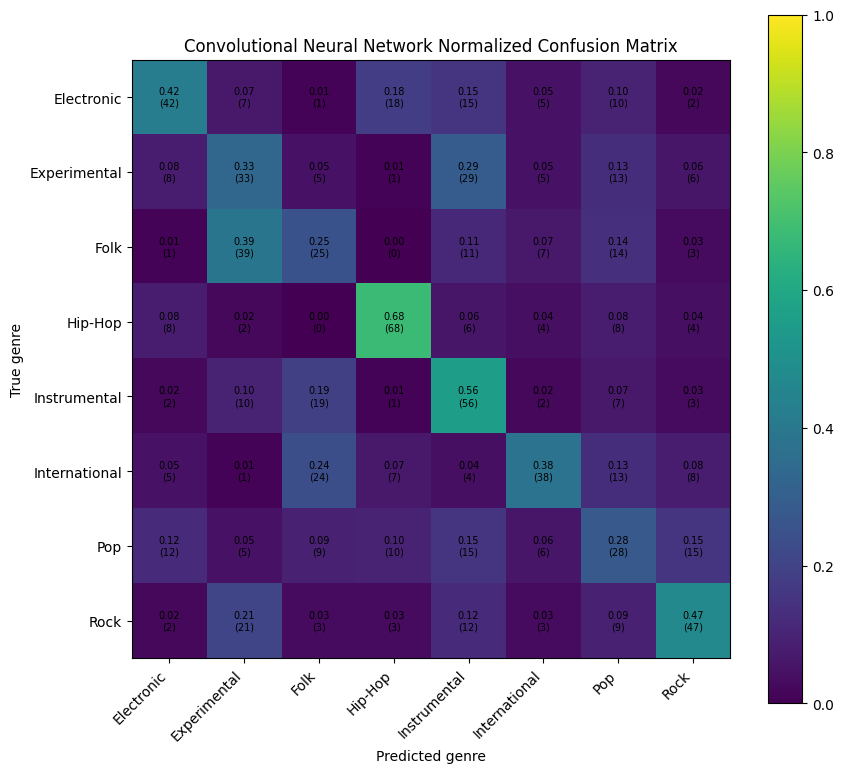

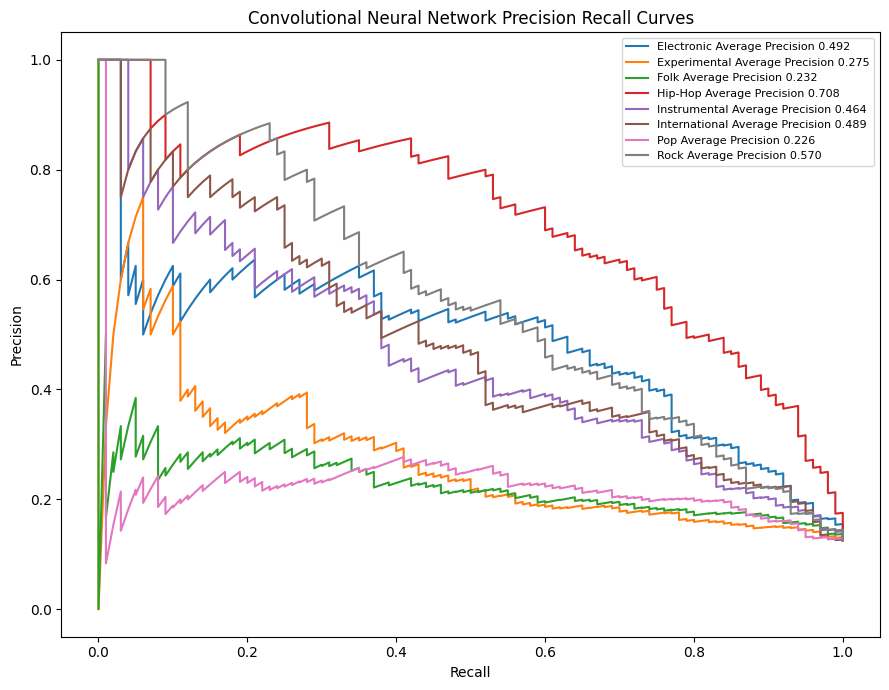

In [47]:
# CELL 41  Convolutional neural network confusion matrix and precision recall curves

cnn_confusion = confusion_matrix(
    cnn_true_labels,
    cnn_predicted_labels,
)

cnn_normalized_confusion = (
    cnn_confusion
    / np.maximum(
        cnn_confusion.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
)

figure, axis = plt.subplots(
    figsize=(9, 8)
)

image = axis.imshow(
    cnn_normalized_confusion,
    vmin=0,
    vmax=1,
)

figure.colorbar(
    image,
    ax=axis,
)

axis.set_xticks(
    range(NUMBER_OF_CLASSES)
)

axis.set_yticks(
    range(NUMBER_OF_CLASSES)
)

axis.set_xticklabels(
    genres,
    rotation=45,
    ha="right",
)

axis.set_yticklabels(
    genres
)

axis.set_xlabel(
    "Predicted genre"
)

axis.set_ylabel(
    "True genre"
)

axis.set_title(
    "Convolutional Neural Network Normalized Confusion Matrix"
)

for row in range(
    NUMBER_OF_CLASSES
):
    for column in range(
        NUMBER_OF_CLASSES
    ):
        axis.text(
            column,
            row,
            (
                f"{cnn_normalized_confusion[row, column]:.2f}"
                f"\n({cnn_confusion[row, column]})"
            ),
            ha="center",
            va="center",
            fontsize=7,
        )

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "cnn_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

binary_cnn_labels = label_binarize(
    cnn_true_labels,
    classes=np.arange(
        NUMBER_OF_CLASSES
    ),
)

plt.figure(figsize=(9, 7))

for class_index in range(
    NUMBER_OF_CLASSES
):
    precision, recall, _ = (
        precision_recall_curve(
            binary_cnn_labels[
                :,
                class_index,
            ],
            cnn_probabilities[
                :,
                class_index,
            ],
        )
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{index_to_genre[class_index]} "
            f"Average Precision "
            f"{cnn_per_class_average_precision[class_index]:.3f}"
        ),
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Convolutional Neural Network Precision Recall Curves"
)

plt.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "cnn_precision_recall_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Final model comparison

All models are evaluated on the same validated FMA small test tracks.

The main comparison uses accuracy, Macro F1 score, Micro F1 score, and Macro Area Under the Precision Recall Curve.

,model,accuracy,macro_f1_score,micro_f1_score,macro_area_under_precision_recall_curve
0,Majority class predictor,0.1250,0.0278,0.1250,0.1250
1,Convolutional neural network log mel baseline,0.4212,0.4210,0.4212,0.4319
2,GraphSAGE musical segment graph,0.4838,0.4805,0.4838,0.4997


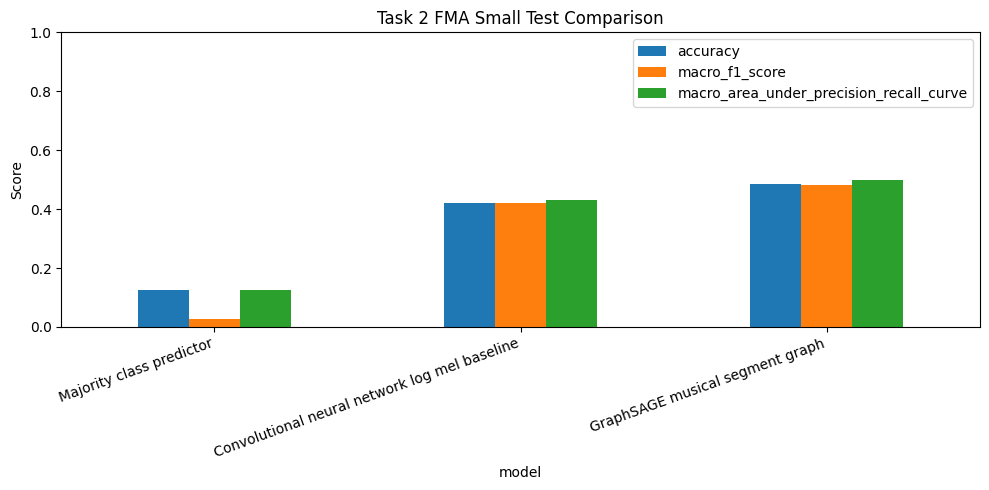

In [48]:
# CELL 42  Final Task 2 comparison table

comparison_table = pd.DataFrame([
    {
        "model": "Majority class predictor",
        "accuracy": majority_metrics["accuracy"],
        "macro_f1_score": majority_metrics["macro_f1"],
        "micro_f1_score": majority_metrics["micro_f1"],
        "macro_area_under_precision_recall_curve": majority_metrics[
            "macro_area_under_precision_recall_curve"
        ],
    },
    {
        "model": "Convolutional neural network log mel baseline",
        "accuracy": cnn_test_metrics["accuracy"],
        "macro_f1_score": cnn_test_metrics["macro_f1"],
        "micro_f1_score": cnn_test_metrics["micro_f1"],
        "macro_area_under_precision_recall_curve": cnn_test_metrics[
            "macro_area_under_precision_recall_curve"
        ],
    },
    {
        "model": "GraphSAGE musical segment graph",
        "accuracy": graphsage_test_metrics["accuracy"],
        "macro_f1_score": graphsage_test_metrics["macro_f1"],
        "micro_f1_score": graphsage_test_metrics["micro_f1"],
        "macro_area_under_precision_recall_curve": graphsage_test_metrics[
            "macro_area_under_precision_recall_curve"
        ],
    },
])

display(
    comparison_table.round(4)
)

comparison_table.to_csv(
    METRICS_DIR
    / "task2_model_comparison.csv",
    index=False,
)

plot_table = (
    comparison_table
    .set_index("model")
    [
        [
            "accuracy",
            "macro_f1_score",
            "macro_area_under_precision_recall_curve",
        ]
    ]
)

axis = plot_table.plot(
    kind="bar",
    figsize=(10, 5),
)

axis.set_ylim(
    0,
    1,
)

axis.set_ylabel(
    "Score"
)

axis.set_title(
    "Task 2 FMA Small Test Comparison"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "task2_model_comparison.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Graph embedding analysis

Graph embeddings are extracted from the held out test set before the final classification layer.

Principal Component Analysis is applied before t distributed Stochastic Neighbor Embedding.

The silhouette score gives a numerical view of genre separation.

In [49]:
# CELL 43  Extract GraphSAGE test embeddings

graphsage_model.eval()

embedding_rows = []
embedding_labels = []
embedding_track_ids = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(
            DEVICE
        )

        graph_embeddings = (
            graphsage_model
            .encode_graph(
                batch
            )
        )

        embedding_rows.append(
            graph_embeddings
            .cpu()
            .numpy()
        )

        embedding_labels.extend(
            batch.y
            .view(-1)
            .cpu()
            .numpy()
        )

        embedding_track_ids.extend(
            batch.track_id
            .view(-1)
            .cpu()
            .numpy()
        )

graph_embeddings = np.concatenate(
    embedding_rows,
    axis=0,
)

embedding_labels = np.asarray(
    embedding_labels
)

embedding_track_ids = np.asarray(
    embedding_track_ids
)

standardized_embeddings = (
    StandardScaler()
    .fit_transform(
        graph_embeddings
    )
)

embedding_silhouette_score = (
    silhouette_score(
        standardized_embeddings,
        embedding_labels,
        metric="cosine",
    )
)

print(
    "Graph embedding shape:",
    graph_embeddings.shape,
)

print(
    "Cosine silhouette score:",
    round(
        float(
            embedding_silhouette_score
        ),
        4,
    ),
)

Graph embedding shape: (800, 192)
Cosine silhouette score: 0.0359


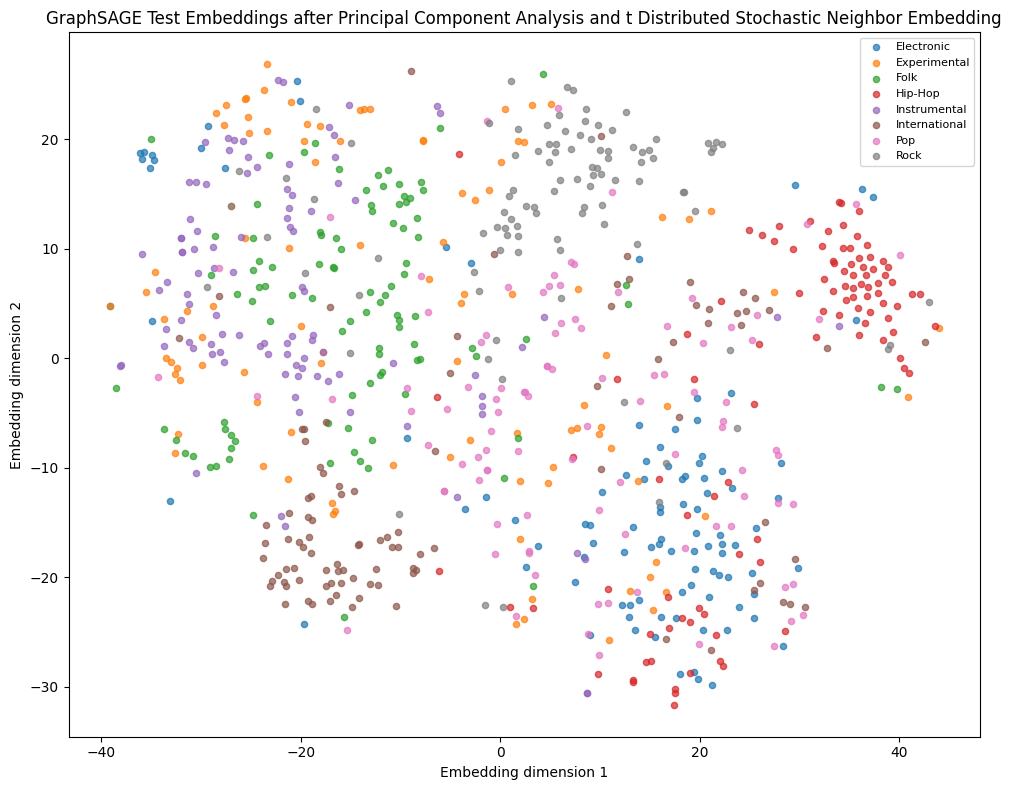

In [50]:
# CELL 44  Principal Component Analysis followed by t distributed Stochastic Neighbor Embedding

principal_component_dimension = min(
    50,
    standardized_embeddings.shape[1],
    standardized_embeddings.shape[0] - 1,
)

principal_components = PCA(
    n_components=principal_component_dimension,
    random_state=SEED,
).fit_transform(
    standardized_embeddings
)

perplexity = min(
    30,
    max(
        5,
        len(principal_components) // 20,
    ),
)

two_dimensional_embeddings = TSNE(
    n_components=2,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    max_iter=1500,
).fit_transform(
    principal_components
)

plt.figure(
    figsize=(10, 8)
)

for class_index in range(
    NUMBER_OF_CLASSES
):
    mask = (
        embedding_labels
        == class_index
    )

    plt.scatter(
        two_dimensional_embeddings[
            mask,
            0,
        ],
        two_dimensional_embeddings[
            mask,
            1,
        ],
        s=20,
        alpha=0.70,
        label=index_to_genre[
            class_index
        ],
    )

plt.legend(
    fontsize=8
)

plt.title(
    "GraphSAGE Test Embeddings after Principal Component Analysis and t Distributed Stochastic Neighbor Embedding"
)

plt.xlabel(
    "Embedding dimension 1"
)

plt.ylabel(
    "Embedding dimension 2"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "graphsage_test_embeddings_tsne.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

pd.DataFrame({
    "track_id": embedding_track_ids,
    "genre": [
        index_to_genre[
            int(label)
        ]
        for label
        in embedding_labels
    ],
    "embedding_dimension_1": (
        two_dimensional_embeddings[
            :,
            0,
        ]
    ),
    "embedding_dimension_2": (
        two_dimensional_embeddings[
            :,
            1,
        ]
    ),
}).to_csv(
    METRICS_DIR
    / "graphsage_test_embeddings_tsne.csv",
    index=False,
)

In [51]:
# CELL 45  Learned graph coherence

def graph_coherence(
    model,
    loader,
    similarity_threshold=0.5,
    maximum_graphs=300,
):
    model.eval()

    coherent_edges = 0
    total_edges = 0
    graphs_seen = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE
            )

            node_embeddings = (
                model.encode_nodes(
                    batch
                )
            )

            node_embeddings = F.normalize(
                node_embeddings,
                dim=1,
            )

            source_nodes, destination_nodes = (
                batch.edge_index
            )

            similarities = (
                node_embeddings[
                    source_nodes
                ]
                * node_embeddings[
                    destination_nodes
                ]
            ).sum(
                dim=1
            )

            coherent_edges += int(
                (
                    similarities
                    > similarity_threshold
                ).sum()
            )

            total_edges += (
                similarities.numel()
            )

            graphs_seen += (
                batch.num_graphs
            )

            if (
                graphs_seen
                >= maximum_graphs
            ):
                break

    return (
        coherent_edges
        / max(
            total_edges,
            1,
        )
    )

learned_graph_coherence = (
    graph_coherence(
        graphsage_model,
        test_loader,
    )
)

print(
    "Learned graph coherence:",
    round(
        learned_graph_coherence,
        4,
    ),
)

Learned graph coherence: 0.9038


# Qualitative predictions

The notebook saves high confidence correct and incorrect GraphSAGE test predictions.

These examples are useful for the report discussion.

In [52]:
# CELL 46  Save qualitative GraphSAGE predictions

qualitative_predictions = pd.DataFrame({
    "track_id": graphsage_track_ids,
    "true_genre": [
        index_to_genre[
            int(index)
        ]
        for index
        in graphsage_true_labels
    ],
    "predicted_genre": [
        index_to_genre[
            int(index)
        ]
        for index
        in graphsage_predicted_labels
    ],
    "prediction_confidence": (
        graphsage_probabilities.max(
            axis=1
        )
    ),
})

qualitative_predictions[
    "correct"
] = (
    qualitative_predictions[
        "true_genre"
    ]
    == qualitative_predictions[
        "predicted_genre"
    ]
)

print(
    "High confidence correct examples"
)

display(
    qualitative_predictions[
        qualitative_predictions[
            "correct"
        ]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False,
    )
    .head(10)
)

print(
    "High confidence incorrect examples"
)

display(
    qualitative_predictions[
        ~qualitative_predictions[
            "correct"
        ]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False,
    )
    .head(10)
)

qualitative_predictions.to_csv(
    EXAMPLES_DIR
    / "graphsage_qualitative_predictions.csv",
    index=False,
)

High confidence correct examples


,track_id,true_genre,predicted_genre,prediction_confidence,correct
326,60874,International,International,0.996347,True
319,60534,International,International,0.995470,True
209,38817,International,International,0.991218,True
316,59695,International,International,0.990085,True
322,60537,International,International,0.989340,True
269,43519,International,International,0.988202,True
207,38784,International,International,0.986185,True
749,144216,Hip-Hop,Hip-Hop,0.985924,True
531,110765,Hip-Hop,Hip-Hop,0.985823,True
530,110764,Hip-Hop,Hip-Hop,0.985646,True


High confidence incorrect examples


,track_id,true_genre,predicted_genre,prediction_confidence,correct
569,113274,International,Rock,0.978291,False
753,145457,Instrumental,Folk,0.972753,False
287,47628,Folk,International,0.959213,False
120,14663,Pop,Electronic,0.953220,False
291,49477,Pop,Hip-Hop,0.940960,False
397,74374,Experimental,Folk,0.938799,False
116,14602,International,Folk,0.938551,False
465,95486,Pop,Electronic,0.920692,False
447,90530,Instrumental,Folk,0.919701,False
652,127189,Pop,Folk,0.919245,False


# Save representative graph samples

The project specification asks for at least 20 example preprocessed graphs.

This notebook saves 24 graph files, with three examples selected from each of the eight genres.

In [53]:
# CELL 47  Copy 24 representative graph samples

for existing_file in SAMPLE_DIR.glob(
    "*.pt"
):
    existing_file.unlink()

sample_records = []

for genre in genres:
    genre_rows = (
        valid_meta[
            valid_meta["genre"]
            == genre
        ]
        .sample(
            n=min(
                3,
                len(
                    valid_meta[
                        valid_meta["genre"]
                        == genre
                    ]
                ),
            ),
            random_state=SEED,
        )
    )

    for _, row in genre_rows.iterrows():
        track_id = int(
            row["track_id"]
        )

        source_path = (
            RAW_GRAPH_DIR
            / f"{track_id:06d}.pt"
        )

        destination_path = (
            SAMPLE_DIR
            / source_path.name
        )

        shutil.copy2(
            source_path,
            destination_path,
        )

        sample_records.append({
            "file": source_path.name,
            "track_id": track_id,
            "genre": row["genre"],
            "split": row["split"],
        })

graph_sample_manifest = pd.DataFrame(
    sample_records
)

graph_sample_manifest.to_csv(
    SAMPLE_DIR
    / "graph_sample_manifest.csv",
    index=False,
)

number_of_graph_samples = len(
    list(
        SAMPLE_DIR.glob(
            "*.pt"
        )
    )
)

print(
    "Saved graph example files:",
    number_of_graph_samples,
)

assert (
    number_of_graph_samples
    >= 20
), "At least 20 graph examples are required."

Saved graph example files: 24


In [54]:
# CELL 48  Save audio decode audit

audio_audit_frame = (
    pd.DataFrame(
        AUDIO_LOG
    )
)

if len(audio_audit_frame):
    audio_audit_frame = (
        audio_audit_frame
        .drop_duplicates(
            subset=["track_id"],
            keep="last",
        )
    )

audio_audit_frame.to_csv(
    METRICS_DIR
    / "audio_decode_audit.csv",
    index=False,
)

print(
    "Audio audit entries:",
    len(audio_audit_frame),
)

if len(audio_audit_frame):
    display(
        audio_audit_frame[
            "backend"
        ].value_counts()
    )

    numeric_audio_audit = (
        audio_audit_frame
        .select_dtypes(
            include=[np.number]
        )
    )

    if len(
        numeric_audio_audit.columns
    ) > 0:
        display(
            numeric_audio_audit.describe()
        )

Audio audit entries: 7993


backend
librosa    7993
Name: count, dtype: int64

,track_id,decoded_seconds_before_padding,peak,rms
count,7993.000000,7993.000000,7993.000000,7993.000000
mean,84107.290004,29.987039,0.864737,0.191141
std,43309.978544,0.011342,0.227578,0.098285
min,2.000000,29.964580,0.000039,0.000008
25%,49061.000000,29.976599,0.752823,0.117504
50%,89192.000000,29.976599,0.941560,0.181991
75%,122578.000000,30.000000,1.002370,0.252427
max,155066.000000,30.000000,2.389272,0.878846


# Save final results and documentation

The GitHub folder contains result tables, plots, split files, 24 graph examples, preprocessing information, configuration, requirements, and a short README file.

Model weights are intentionally excluded.

In [55]:
# CELL 49  Save final metrics and experiment configuration

final_metrics = {
    "majority_class_predictor": majority_metrics,
    "convolutional_neural_network_baseline": cnn_test_metrics,
    "graphsage": graphsage_test_metrics,
    "learned_graph_coherence": float(
        learned_graph_coherence
    ),
    "graph_embedding_cosine_silhouette_score": float(
        embedding_silhouette_score
    ),
    "best_graphsage_epoch": int(
        best_graphsage_epoch
    ),
    "best_cnn_epoch": int(
        best_cnn_epoch
    ),
}

with open(
    METRICS_DIR
    / "final_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_metrics,
        file,
        indent=2,
    )

experiment_config = {
    "dataset": "FMA small",
    "official_split": True,
    "sample_rate": SR,
    "duration_seconds": DURATION,
    "segmentation": (
        "Four beat groups with fixed three second fallback"
    ),
    "beats_per_node": BEATS_PER_NODE,
    "node_feature_dimension": 228,
    "node_features": [
        "64 bin log mel mean and standard deviation",
        "20 MFCC mean and standard deviation",
        "12 chroma mean and standard deviation",
        "7 spectral contrast mean and standard deviation",
        "6 tonnetz mean and standard deviation",
        "spectral centroid bandwidth rolloff zero crossing rate and root mean square mean and standard deviation",
    ],
    "normalization": (
        "StandardScaler fitted on training graph nodes only"
    ),
    "edge_types": [
        "temporal adjacency",
        "cosine similarity",
    ],
    "similarity_threshold": SIM_THRESHOLD,
    "similarity_top_k": SIM_TOP_K,
    "graph_model": (
        "Two layer residual GraphSAGE with global mean pooling"
    ),
    "graph_hidden_dimension": GNN_HIDDEN,
    "graph_batch_size": BATCH_SIZE_GNN,
    "graph_learning_rate": LR_GNN,
    "graph_maximum_epochs": EPOCHS_GNN,
    "cnn_model": (
        "Residual convolutional neural network on 128 bin log mel spectrograms"
    ),
    "cnn_batch_size": BATCH_SIZE_CNN,
    "cnn_learning_rate": LR_CNN,
    "cnn_maximum_epochs": EPOCHS_CNN,
    "loss": (
        "Cross entropy loss with training label smoothing"
    ),
    "label_smoothing": LABEL_SMOOTHING,
    "model_weights_saved": False,
    "large_runtime_caches_included_in_zip": False,
    "number_of_saved_graph_examples": int(
        number_of_graph_samples
    ),
    "fast_development_run": FAST_DEV_RUN,
    "seed": SEED,
}

with open(
    CONFIG_DIR
    / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_config,
        file,
        indent=2,
    )

main_result_summary = comparison_table.copy()

main_result_summary.to_csv(
    METRICS_DIR
    / "task2_main_result_summary.csv",
    index=False,
)

In [56]:
# CELL 50  Create README and requirements

readme_text = f"""# Task 2 FMA Small GraphSAGE

# Goal

Task 2 builds musical segment graphs from FMA small audio and predicts eight music genres with GraphSAGE.

A convolutional neural network on log mel spectrograms and a majority class predictor are used as baselines.

# Graph construction

Audio sample rate: {SR}

Track duration: {DURATION} seconds

Main segmentation: groups of {BEATS_PER_NODE} beats

Fallback segmentation: {FALLBACK_SEGMENT_SEC} seconds

Node feature dimension: 228

Graph edges: temporal adjacency plus cosine similarity edges

Cosine similarity threshold: {SIM_THRESHOLD}

Maximum additional similarity neighbors per node: {SIM_TOP_K}

# Models

Main model: two layer residual GraphSAGE with global mean pooling

Baseline one: residual convolutional neural network on 128 bin log mel spectrograms

Baseline two: majority class predictor

# Main GraphSAGE Result

Accuracy: {graphsage_test_metrics['accuracy']:.4f}

Macro F1 score: {graphsage_test_metrics['macro_f1']:.4f}

Micro F1 score: {graphsage_test_metrics['micro_f1']:.4f}

Macro Area Under the Precision Recall Curve: {graphsage_test_metrics['macro_area_under_precision_recall_curve']:.4f}

Best GraphSAGE Epoch: {best_graphsage_epoch}

# Convolutional Neural Network Baseline Result

Accuracy: {cnn_test_metrics['accuracy']:.4f}

Macro F1 score: {cnn_test_metrics['macro_f1']:.4f}

Micro F1 score: {cnn_test_metrics['micro_f1']:.4f}

Macro Area Under the Precision Recall Curve: {cnn_test_metrics['macro_area_under_precision_recall_curve']:.4f}

Best Convolutional Neural Network Epoch: {best_cnn_epoch}

# Folder Contents

data_splits contains the official training validation and test track lists used by the experiment.

metrics contains graph audits, training histories, classification reports, final comparison tables, predictions, and numerical summaries.

plots contains dataset, graph, training, confusion matrix, precision recall, comparison, and embedding figures.

graph_samples_24 contains 24 representative preprocessed PyTorch Geometric graph files.

examples contains qualitative GraphSAGE predictions.

config contains the genre mapping and experiment configuration.

preprocessing contains the training only StandardScaler used for graph node features.

# Important Notes

The official FMA split is used.

The node StandardScaler is fitted on training nodes only.

Large raw graph and log mel caches are not included because they can be regenerated and are too large for GitHub.

Model weights are not included.

The final ZIP file contains the complete GitHub result folder.
"""

with open(
    GITHUB_DIR / "README.md",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        readme_text
    )

requirements_text = """torch
torch-geometric
librosa==0.10.2.post1
soundfile
joblib
networkx
numpy
pandas
matplotlib
scikit-learn
"""

with open(
    GITHUB_DIR
    / "requirements.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        requirements_text
    )

In [57]:
# CELL 51  Verify folder tree create ZIP and provide a relative Kaggle download link

expected_files = [
    GITHUB_DIR / "README.md",
    GITHUB_DIR / "requirements.txt",
    CONFIG_DIR / "experiment_config.json",
    CONFIG_DIR / "genre_mapping.json",
    PREPROCESSING_DIR / "training_node_scaler.joblib",
    SPLIT_DIR / "training.json",
    SPLIT_DIR / "validation.json",
    SPLIT_DIR / "test.json",
    METRICS_DIR / "final_metrics.json",
    METRICS_DIR / "task2_model_comparison.csv",
    METRICS_DIR / "graphsage_training_history.csv",
    METRICS_DIR / "cnn_training_history.csv",
    METRICS_DIR / "graph_audit.csv",
    PLOT_DIR / "task2_model_comparison.png",
    PLOT_DIR / "graphsage_loss.png",
    PLOT_DIR / "graphsage_macro_f1_score.png",
    PLOT_DIR / "cnn_loss.png",
    PLOT_DIR / "cnn_macro_f1_score.png",
    PLOT_DIR / "graphsage_confusion_matrix.png",
    PLOT_DIR / "cnn_confusion_matrix.png",
    PLOT_DIR / "graphsage_test_embeddings_tsne.png",
    SAMPLE_DIR / "graph_sample_manifest.csv",
    EXAMPLES_DIR / "graphsage_qualitative_predictions.csv",
]

missing_expected_files = [
    str(path)
    for path in expected_files
    if not path.exists()
]

assert not missing_expected_files, (
    "Expected GitHub files are missing: "
    + str(
        missing_expected_files
    )
)

saved_graph_files = list(
    SAMPLE_DIR.glob(
        "*.pt"
    )
)

assert len(
    saved_graph_files
) >= 20, (
    "At least 20 graph sample files must exist."
)

manifest_rows = []

for path in sorted(
    GITHUB_DIR.rglob("*")
):
    if path.is_file():
        manifest_rows.append({
            "relative_path": str(
                path.relative_to(
                    GITHUB_DIR
                )
            ),
            "size_kilobytes": round(
                path.stat().st_size
                / 1024,
                2,
            ),
        })

folder_manifest = pd.DataFrame(
    manifest_rows
)

folder_manifest.to_csv(
    GITHUB_DIR
    / "folder_manifest.csv",
    index=False,
)

print(
    "Verified GitHub folder:"
)

print(
    GITHUB_DIR
)

print()

print(
    "Folder tree"
)

for path in sorted(
    GITHUB_DIR.rglob("*")
):
    relative_path = (
        path.relative_to(
            GITHUB_DIR
        )
    )

    depth = len(
        relative_path.parts
    ) - 1

    prefix = (
        "    " * depth
    )

    if path.is_dir():
        print(
            f"{prefix}{path.name}/"
        )
    else:
        print(
            f"{prefix}{path.name} "
            f"({path.stat().st_size / 1024:.1f} KB)"
        )

zip_base = (
    KAGGLE_WORKING
    / "task2_fma_github_download"
)

zip_file = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(
        KAGGLE_WORKING
    ),
    base_dir=GITHUB_DIR.name,
)

zip_path = Path(
    zip_file
)

assert zip_path.exists()

print()

print(
    "ZIP file created successfully:"
)

print(
    zip_path
)

print(
    "ZIP size in megabytes:",
    round(
        zip_path.stat().st_size
        / (
            1024
            * 1024
        ),
        2,
    ),
)

print()

print(
    "Click the relative link below to download the complete folder."
)

print(
    "If the link does not open, save a Kaggle notebook version and download the same ZIP from the Output section."
)

from IPython.display import FileLink, display

current_directory = os.getcwd()

try:
    os.chdir(
        KAGGLE_WORKING
    )

    display(
        FileLink(
            "task2_fma_github_download.zip"
        )
    )

finally:
    os.chdir(
        current_directory
    )

Verified GitHub folder:
/kaggle/working/task2_fma_github

Folder tree
README.md (2.1 KB)
config/
    experiment_config.json (1.4 KB)
    genre_mapping.json (0.4 KB)
data_splits/
    test.json (74.8 KB)
    training.json (600.1 KB)
    validation.json (75.1 KB)
examples/
    graphsage_qualitative_predictions.csv (32.1 KB)
folder_manifest.csv (2.5 KB)
graph_samples_24/
    038887.pt (18.6 KB)
    040541.pt (14.0 KB)
    045475.pt (25.6 KB)
    052637.pt (14.1 KB)
    059707.pt (14.2 KB)
    064864.pt (19.4 KB)
    075745.pt (18.3 KB)
    085598.pt (24.7 KB)
    085834.pt (21.4 KB)
    088861.pt (19.3 KB)
    088960.pt (13.3 KB)
    094034.pt (19.4 KB)
    107181.pt (21.9 KB)
    107184.pt (15.2 KB)
    117627.pt (17.4 KB)
    117630.pt (18.3 KB)
    119026.pt (15.2 KB)
    119901.pt (14.2 KB)
    122807.pt (22.6 KB)
    122810.pt (23.5 KB)
    123501.pt (17.4 KB)
    123980.pt (15.3 KB)
    127330.pt (17.4 KB)
    133436.pt (15.4 KB)
    graph_sample_manifest.csv (0.8 KB)
metrics/
    ar

/kaggle/working/task2_fma_github_download.zip